In [18]:
import os
import numpy as np
from PIL import Image, ImageEnhance, ImageOps
import random

def augment_image(img):
    """Apply random augmentation to an image"""
    augmentations = [
        lambda x: x.rotate(random.uniform(-15, 15), fillcolor=(0, 0, 0)),  # Random rotation
        lambda x: ImageEnhance.Brightness(x).enhance(random.uniform(0.8, 1.2)),  # Brightness
        lambda x: ImageEnhance.Contrast(x).enhance(random.uniform(0.8, 1.2)),  # Contrast
        lambda x: x.transpose(Image.FLIP_LEFT_RIGHT),  # Horizontal flip
        lambda x: ImageOps.autocontrast(x),  # Auto contrast
        lambda x: x.rotate(random.uniform(-10, 10), fillcolor=(0, 0, 0)),  # Slight rotation
    ]

    # Apply 1-2 random augmentations
    num_augs = random.randint(1, 2)
    selected_augs = random.sample(augmentations, num_augs)

    augmented = img.copy()
    for aug in selected_augs:
        augmented = aug(augmented)

    return augmented

def process_identity_folders(base_folder, target_count=100):
    """Process each identity folder and augment to reach target count"""

    # Get all subdirectories (identity folders)
    identity_folders = [f for f in os.listdir(base_folder)
                       if os.path.isdir(os.path.join(base_folder, f))]

    print(f"Found {len(identity_folders)} identity folders")

    for identity_folder in identity_folders:
        folder_path = os.path.join(base_folder, identity_folder)

        # Get all image files in the folder
        image_files = [f for f in os.listdir(folder_path)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]

        current_count = len(image_files)

        if current_count >= target_count:
            print(f"✓ {identity_folder}: {current_count} images (no augmentation needed)")
            continue

        needed = target_count - current_count
        print(f"→ {identity_folder}: {current_count} images, need {needed} more")

        # Load existing images
        images = []
        for img_file in image_files:
            try:
                img_path = os.path.join(folder_path, img_file)
                img = Image.open(img_path).convert('RGB')
                images.append(img)
            except Exception as e:
                print(f"  Warning: Could not load {img_file}: {e}")

        if len(images) == 0:
            print(f"  Error: No valid images in {identity_folder}")
            continue

        # Generate augmented images
        augmented_count = 0
        while augmented_count < needed:
            # Randomly select a source image
            source_img = random.choice(images)

            # Augment it
            augmented_img = augment_image(source_img)

            # Save with a unique name
            aug_filename = f"aug_{augmented_count:04d}.jpg"
            aug_path = os.path.join(folder_path, aug_filename)

            augmented_img.save(aug_path, quality=95)
            augmented_count += 1

        print(f"  ✓ Generated {augmented_count} augmented images")

        # Verify final count
        final_count = len([f for f in os.listdir(folder_path)
                          if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))])
        print(f"  Final count: {final_count} images")

# Usage
base_folder = '/content/drive/MyDrive/archive (1)/Celebrity Image Subsets'  # Change this to your folder path
process_identity_folders(base_folder, target_count=100)
print("\nAugmentation complete!")

Found 46 identity folders
✓ images__447_: 101 images (no augmentation needed)
✓ images__3227_: 100 images (no augmentation needed)
✓ images__2820_: 100 images (no augmentation needed)
✓ images__2425_: 100 images (no augmentation needed)
✓ images__2880_: 100 images (no augmentation needed)
✓ images__7904_: 100 images (no augmentation needed)
✓ images__1158_: 100 images (no augmentation needed)
✓ images__8265_: 100 images (no augmentation needed)
✓ images__4126_: 100 images (no augmentation needed)
✓ images__8968_: 100 images (no augmentation needed)
✓ images__3698_: 100 images (no augmentation needed)
✓ images__6568_: 100 images (no augmentation needed)
✓ images__8656_: 100 images (no augmentation needed)
✓ images__10173_: 100 images (no augmentation needed)
✓ images__3745_: 100 images (no augmentation needed)
✓ images__9063_: 100 images (no augmentation needed)
✓ images__1499_: 100 images (no augmentation needed)
→ images__2562_: 30 images, need 70 more
  ✓ Generated 70 augmented image

In [21]:
!pip install face-recognition

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 10.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=690ebabf6397f54c73ddef124c706dfd20b5d9504359f3f26e72ca424752d57e
  Stored in directory: /root/.cache/pip/wheels/8f/47/c8/f44c5aebb7507f7c8a2c0bd23151d732d0f0bd6884ad4ac635
Successfully built face-recognition-models


In [26]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split

def extract_identity_number(folder_name):
    """Extract identity number from folder name like 'images__8722_'"""
    import re
    numbers = re.findall(r'\d+', folder_name)
    if numbers:
        return int(numbers[0])
    return None

def split_dataset_yolo_classification(base_folder, output_folder='dataset_yolo', test_size=0.2, val_size=0.1, random_state=42):
    """Split identity folders into train/val/test sets for YOLO classification

    YOLO classification expects this structure:
    dataset/
    ├── train/
    │   ├── class_0/
    │   ├── class_1/
    │   └── ...
    ├── val/
    │   ├── class_0/
    │   ├── class_1/
    │   └── ...
    └── test/
        ├── class_0/
        ├── class_1/
        └── ...
    """

    random.seed(random_state)

    # Create output directories
    train_dir = os.path.join(output_folder, 'train')
    val_dir = os.path.join(output_folder, 'val')
    test_dir = os.path.join(output_folder, 'test')

    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)

    # Get all identity folders
    identity_folders = [f for f in os.listdir(base_folder)
                       if os.path.isdir(os.path.join(base_folder, f))]

    identity_folders.sort()

    print(f"Found {len(identity_folders)} identity folders")

    if len(identity_folders) == 0:
        print("ERROR: No identity folders found!")
        return

    train_pct = int((1 - test_size - val_size) * 100)
    val_pct = int(val_size * 100)
    test_pct = int(test_size * 100)

    print(f"Splitting with {train_pct}% train, {val_pct}% val, {test_pct}% test\n")

    # Create label mapping
    label_mapping = {}
    for folder_name in identity_folders:
        identity_num = extract_identity_number(folder_name)
        if identity_num is not None:
            label_mapping[folder_name] = identity_num
        else:
            print(f"Warning: Could not extract number from folder name: {folder_name}")

    # Save label mapping
    mapping_file = os.path.join(output_folder, 'label_mapping.txt')
    with open(mapping_file, 'w') as f:
        f.write("FolderName,IdentityNumber,ClassIndex\n")
        for idx, folder_name in enumerate(sorted(label_mapping.keys(), key=lambda x: label_mapping[x])):
            f.write(f"{folder_name},{label_mapping[folder_name]},{idx}\n")

    print(f"Label mapping saved to {mapping_file}\n")

    # Process each identity
    train_count = 0
    val_count = 0
    test_count = 0

    for class_idx, folder_name in enumerate(sorted(label_mapping.keys(), key=lambda x: label_mapping[x])):
        if folder_name not in label_mapping:
            continue

        identity_path = os.path.join(base_folder, folder_name)
        identity_num = label_mapping[folder_name]

        # Create class folders in train/val/test
        train_class_dir = os.path.join(train_dir, str(class_idx))
        val_class_dir = os.path.join(val_dir, str(class_idx))
        test_class_dir = os.path.join(test_dir, str(class_idx))

        os.makedirs(train_class_dir, exist_ok=True)
        os.makedirs(val_class_dir, exist_ok=True)
        os.makedirs(test_class_dir, exist_ok=True)

        # Get all images from this identity
        image_files = [f for f in os.listdir(identity_path)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]

        if len(image_files) == 0:
            print(f"Warning: No images found in {folder_name}")
            continue

        # Split images
        train_val_images, test_images = train_test_split(
            image_files,
            test_size=test_size,
            random_state=random_state
        )

        val_size_adjusted = val_size / (1 - test_size)
        train_images, val_images = train_test_split(
            train_val_images,
            test_size=val_size_adjusted,
            random_state=random_state
        )

        # Copy training images
        for img_file in train_images:
            src_path = os.path.join(identity_path, img_file)
            dst_path = os.path.join(train_class_dir, img_file)
            shutil.copy2(src_path, dst_path)
            train_count += 1

        # Copy validation images
        for img_file in val_images:
            src_path = os.path.join(identity_path, img_file)
            dst_path = os.path.join(val_class_dir, img_file)
            shutil.copy2(src_path, dst_path)
            val_count += 1

        # Copy test images
        for img_file in test_images:
            src_path = os.path.join(identity_path, img_file)
            dst_path = os.path.join(test_class_dir, img_file)
            shutil.copy2(src_path, dst_path)
            test_count += 1

        aug_in_train = len([f for f in train_images if f.startswith('aug_')])
        aug_in_val = len([f for f in val_images if f.startswith('aug_')])
        aug_in_test = len([f for f in test_images if f.startswith('aug_')])

        print(f"✓ Class {class_idx} - {folder_name} (ID: {identity_num}): "
              f"{len(train_images)} train ({aug_in_train} aug), "
              f"{len(val_images)} val ({aug_in_val} aug), "
              f"{len(test_images)} test ({aug_in_test} aug)")

    print(f"\n{'='*60}")
    print(f"Split complete!")
    print(f"Train: {train_count} images ({train_count/(train_count+val_count+test_count)*100:.1f}%)")
    print(f"Val:   {val_count} images ({val_count/(train_count+val_count+test_count)*100:.1f}%)")
    print(f"Test:  {test_count} images ({test_count/(train_count+val_count+test_count)*100:.1f}%)")
    print(f"{'='*60}")
    print(f"\nDataset structure (YOLO Classification format):")
    print(f"{output_folder}/")
    print(f"├── train/")
    print(f"│   ├── 0/  (class 0 images)")
    print(f"│   ├── 1/  (class 1 images)")
    print(f"│   └── ...")
    print(f"├── val/")
    print(f"│   ├── 0/")
    print(f"│   └── ...")
    print(f"├── test/")
    print(f"│   ├── 0/")
    print(f"│   └── ...")
    print(f"└── label_mapping.txt")

# Usage
base_folder = '/content/drive/MyDrive/archive (1)/Celebrity Image Subsets'
split_dataset_yolo_classification(base_folder, output_folder='/content/dataset_yolo', test_size=0.2, val_size=0.1)

Found 46 identity folders
Splitting with 70% train, 10% val, 20% test

Label mapping saved to /content/dataset_yolo/label_mapping.txt

✓ Class 0 - images__228_ (ID: 228): 70 train (57 aug), 10 val (7 aug), 20 test (15 aug)
✓ Class 1 - images__447_ (ID: 447): 70 train (50 aug), 10 val (5 aug), 21 test (15 aug)
✓ Class 2 - images__487_ (ID: 487): 70 train (50 aug), 10 val (6 aug), 20 test (14 aug)
✓ Class 3 - images__619_ (ID: 619): 70 train (62 aug), 10 val (7 aug), 20 test (16 aug)
✓ Class 4 - images__800_ (ID: 800): 70 train (50 aug), 10 val (6 aug), 20 test (14 aug)
✓ Class 5 - images__1158_ (ID: 1158): 70 train (55 aug), 10 val (7 aug), 20 test (14 aug)
✓ Class 6 - images__1499_ (ID: 1499): 70 train (50 aug), 10 val (6 aug), 20 test (14 aug)
✓ Class 7 - images__1852_ (ID: 1852): 70 train (50 aug), 10 val (6 aug), 20 test (14 aug)
✓ Class 8 - images__1964_ (ID: 1964): 70 train (56 aug), 10 val (7 aug), 20 test (14 aug)
✓ Class 9 - images__2425_ (ID: 2425): 70 train (50 aug), 10 val (

In [7]:
!pip install -r "/content/drive/MyDrive/archive (1)/requirements.txt" -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.3/128.3 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 84.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 74.3 MB/s eta 0:00:00


In [8]:
# Import necessary libraries
from ultralytics import YOLO
from ultralytics.engine.results import Results
from deepface import DeepFace
from PIL import Image
import gradio as gr
import shutil
import pandas
import cv2
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
25-10-05 04:53:11 - Directory /root/.deepface has been created
25-10-05 04:53:11 - Directory /root/.deepface/weights has been created


In [28]:
model = YOLO('yolov8n-cls.pt')

In [5]:
results = model.val()

# Test on test set
results = model.predict(source='/content/dataset_yolo/test', save=True)

Ultralytics 8.3.204 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


FileNotFoundError: 'datasets/data.yaml' does not exist

In [32]:
import os
from ultralytics import YOLO

model = YOLO('runs/classify/train/weights/best.pt')  # Load your trained model

test_dir = '/content/dataset_yolo/test'

# Get all class folders
class_folders = [f for f in os.listdir(test_dir) if os.path.isdir(os.path.join(test_dir, f))]

all_results = []

for class_folder in sorted(class_folders):
    class_path = os.path.join(test_dir, class_folder)
    print(f"Testing on class {class_folder}...")

    # Predict on this class folder
    results = model.predict(
        source=class_path,
        save=True,
        imgsz=224,
        conf=0.5
    )

    all_results.extend(results)

print(f"\nCompleted predictions on {len(all_results)} images")

FileNotFoundError: [Errno 2] No such file or directory: 'runs/classify/train/weights/best.pt'

In [2]:
import os

def check_dataset_structure(dataset_path):
    """Check if dataset has correct YOLO classification structure"""

    print(f"Checking dataset at: {dataset_path}\n")

    required_folders = ['train', 'val']
    optional_folders = ['test']

    # Check main folders
    for folder in required_folders + optional_folders:
        folder_path = os.path.join(dataset_path, folder)
        if os.path.exists(folder_path):
            # Count class folders
            class_folders = [f for f in os.listdir(folder_path)
                           if os.path.isdir(os.path.join(folder_path, f))]

            # Count images in each class
            total_images = 0
            for class_folder in class_folders[:3]:  # Show first 3 classes
                class_path = os.path.join(folder_path, class_folder)
                images = [f for f in os.listdir(class_path)
                         if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]
                total_images += len(images)
                print(f"  ✓ {folder}/{class_folder}: {len(images)} images")

            if len(class_folders) > 3:
                print(f"  ... and {len(class_folders) - 3} more classes")

            print(f"  Total: {len(class_folders)} classes\n")
        else:
            if folder in required_folders:
                print(f"  ❌ {folder}/ - MISSING (required)\n")
            else:
                print(f"  ⚠️  {folder}/ - missing (optional)\n")

check_dataset_structure('/content/dataset_yolo')

Checking dataset at: /content/dataset_yolo

  ✓ train/14: 70 images
  ✓ train/5: 70 images
  ✓ train/34: 70 images
  ... and 42 more classes
  Total: 45 classes

  ✓ val/14: 10 images
  ✓ val/5: 10 images
  ✓ val/34: 10 images
  ... and 42 more classes
  Total: 45 classes

  ✓ test/14: 20 images
  ✓ test/5: 20 images
  ✓ test/34: 20 images
  ... and 42 more classes
  Total: 45 classes



In [3]:
from ultralytics import YOLO
import os

# Verify dataset structure
print("Verifying dataset...")
if os.path.exists('/content/dataset_yolo/train') and os.path.exists('/content/dataset_yolo/val'):
    train_classes = len([f for f in os.listdir('/content/dataset_yolo/train')
                        if os.path.isdir(os.path.join('/content/dataset_yolo/train', f))])
    val_classes = len([f for f in os.listdir('/content/dataset_yolo/val')
                      if os.path.isdir(os.path.join('/content/dataset_yolo/val', f))])
    print(f"✓ Dataset ready: {train_classes} classes in train, {val_classes} classes in val\n")
else:
    print("❌ Dataset structure incorrect!")
    exit()

# Load CLASSIFICATION model (not detection!)
print("Loading classification model...")
model = YOLO('yolov8n-cls.pt')  # Must use -cls model!

# Train
print("Starting training...\n")
results = model.train(
    data='/content/dataset_yolo',
    epochs=202,
    imgsz=640,
    batch=16,
    patience=50,
    save=True,
    save_period=10,
    project='runs/classify',
    name='face_recognition',
    device=0,
    verbose=True
)

print("\n✓ Training complete!")
print(f"Best model saved at: runs/classify/face_recognition/weights/best.pt")

Verifying dataset...
✓ Dataset ready: 45 classes in train, 45 classes in val

Loading classification model...
Starting training...

Ultralytics 8.3.204 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_yolo, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=202, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=face_recogn

In [4]:
model = YOLO('/content/drive/MyDrive/archive (1)/best.pt')

In [6]:
from ultralytics import YOLO
import os

# Load the best model from training
model_path = 'runs/classify/face_recognition/weights/best.pt'

if os.path.exists(model_path):
    print(f"✓ Model found at: {model_path}")
    model = YOLO(model_path)

    # Check training results
    from IPython.display import Image, display

    print("\n📊 Training Results:")
    if os.path.exists('runs/classify/face_recognition/results.png'):
        display(Image('runs/classify/face_recognition/results.png'))
else:
    print(f"❌ Model not found at {model_path}")
    # Find where it was actually saved
    import glob
    models = glob.glob('runs/**/weights/best.pt', recursive=True)
    print("\nAvailable models:")
    for m in models:
        print(f"  {m}")

❌ Model not found at runs/classify/face_recognition/weights/best.pt

Available models:
  runs/classify/train2/weights/best.pt
  runs/classify/face_recognition3/weights/best.pt
  runs/detect/train3/weights/best.pt


✓ Loading model from: runs/classify/face_recognition3/weights/best.pt

📊 Training Results:


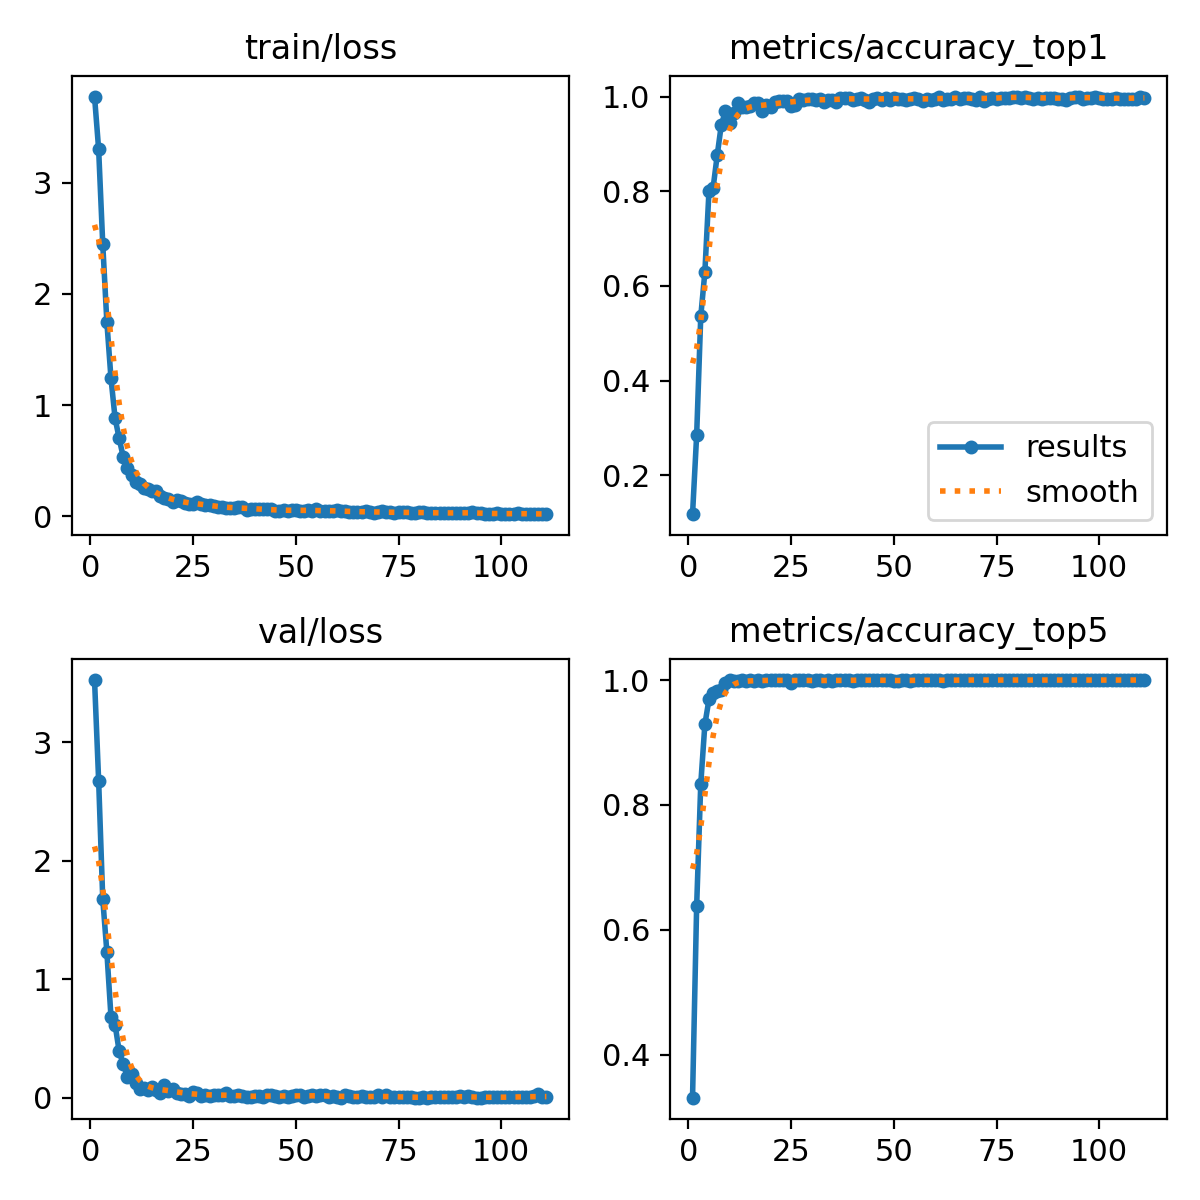

In [7]:
from ultralytics import YOLO
import os

# Use the most recent classification model
# (face_recognition3 seems to be your latest)
model_path = 'runs/classify/face_recognition3/weights/best.pt'

if os.path.exists(model_path):
    print(f"✓ Loading model from: {model_path}")
    model = YOLO(model_path)

    # Check training results
    from IPython.display import Image, display

    print("\n📊 Training Results:")
    results_path = 'runs/classify/face_recognition3/results.png'
    if os.path.exists(results_path):
        display(Image(results_path))
    else:
        print("Results plot not found")
else:
    print(f"❌ Model not found")

In [8]:
from ultralytics import YOLO
import os

# Load your trained model (use the latest one)
model = YOLO('runs/classify/face_recognition3/weights/best.pt')

# Evaluate on test set
print("="*60)
print("TESTING ON TEST SET")
print("="*60)

test_dir = '/content/dataset_yolo/test'
class_folders = sorted([f for f in os.listdir(test_dir)
                       if os.path.isdir(os.path.join(test_dir, f))])

correct = 0
total = 0
top5_correct = 0
per_class_stats = {}

print(f"Testing on {len(class_folders)} classes...\n")

for class_folder in class_folders:
    class_path = os.path.join(test_dir, class_folder)
    images = [f for f in os.listdir(class_path)
             if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]

    class_correct = 0
    class_total = len(images)

    for img_file in images:
        img_path = os.path.join(class_path, img_file)

        # Predict
        result = model(img_path, verbose=False)
        pred_class = result[0].probs.top1

        # Check top-1
        if pred_class == int(class_folder):
            correct += 1
            class_correct += 1

        # Check top-5
        top5_indices = result[0].probs.top5
        if int(class_folder) in top5_indices:
            top5_correct += 1

        total += 1

    per_class_stats[class_folder] = {
        'correct': class_correct,
        'total': class_total,
        'accuracy': (class_correct / class_total * 100) if class_total > 0 else 0
    }

    # Print progress every 10 classes
    if int(class_folder) % 10 == 0:
        print(f"Progress: Tested {int(class_folder)+1}/{len(class_folders)} classes...")

# Print overall results
print(f"\n{'='*60}")
print(f"OVERALL TEST RESULTS")
print(f"{'='*60}")
print(f"Total images tested: {total}")
print(f"Top-1 Accuracy: {correct}/{total} = {(correct/total*100):.2f}%")
print(f"Top-5 Accuracy: {top5_correct}/{total} = {(top5_correct/total*100):.2f}%")
print(f"{'='*60}")

# Print per-class accuracy (first 10 classes)
print("\nPer-Class Accuracy (first 10 classes):")
for i, class_idx in enumerate(sorted(per_class_stats.keys(), key=lambda x: int(x))[:10]):
    stats = per_class_stats[class_idx]
    print(f"  Class {class_idx}: {stats['correct']}/{stats['total']} = {stats['accuracy']:.1f}%")

if len(per_class_stats) > 10:
    print(f"  ... and {len(per_class_stats) - 10} more classes")

# Find best and worst performing classes
best_class = max(per_class_stats.items(), key=lambda x: x[1]['accuracy'])
worst_class = min(per_class_stats.items(), key=lambda x: x[1]['accuracy'])

print(f"\n🏆 Best performing class: {best_class[0]} ({best_class[1]['accuracy']:.1f}%)")
print(f"⚠️  Worst performing class: {worst_class[0]} ({worst_class[1]['accuracy']:.1f}%)")

# Calculate average per-class accuracy
avg_per_class = sum(s['accuracy'] for s in per_class_stats.values()) / len(per_class_stats)
print(f"📊 Average per-class accuracy: {avg_per_class:.2f}%")

TESTING ON TEST SET
Testing on 45 classes...

Progress: Tested 1/45 classes...
Progress: Tested 11/45 classes...
Progress: Tested 21/45 classes...
Progress: Tested 31/45 classes...
Progress: Tested 41/45 classes...

OVERALL TEST RESULTS
Total images tested: 901
Top-1 Accuracy: 41/901 = 4.55%
Top-5 Accuracy: 117/901 = 12.99%

Per-Class Accuracy (first 10 classes):
  Class 0: 20/20 = 100.0%
  Class 1: 21/21 = 100.0%
  Class 2: 0/20 = 0.0%
  Class 3: 0/20 = 0.0%
  Class 4: 0/20 = 0.0%
  Class 5: 0/20 = 0.0%
  Class 6: 0/20 = 0.0%
  Class 7: 0/20 = 0.0%
  Class 8: 0/20 = 0.0%
  Class 9: 0/20 = 0.0%
  ... and 35 more classes

🏆 Best performing class: 0 (100.0%)
⚠️  Worst performing class: 10 (0.0%)
📊 Average per-class accuracy: 4.44%


In [13]:
from ultralytics import YOLO
import os

model = YOLO('runs/classify/face_recognition3/weights/best.pt')

test_dir = '/content/dataset_yolo/test'
class_folders = sorted([f for f in os.listdir(test_dir)
                       if os.path.isdir(os.path.join(test_dir, f))])

print("Checking first 5 classes:\n")

for class_folder in class_folders[:5]:
    class_path = os.path.join(test_dir, class_folder)
    images = [f for f in os.listdir(class_path)
             if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]

    if images:
        img_path = os.path.join(class_path, images[0])
        result = model(img_path, verbose=False)

        pred_class = result[0].probs.top1
        pred_conf = result[0].probs.top1conf.item()
        true_class = int(class_folder)

        match = "✓" if pred_class == true_class else "✗"
        print(f"{match} True: {true_class} | Predicted: {pred_class} ({pred_conf*100:.2f}%)")

        # Show top 5 predictions - simplified
        top5 = result[0].probs.top5
        top5_conf = result[0].probs.top5conf

        print(f"  Top 5 predictions:")
        for i, (cls, conf) in enumerate(zip(top5, top5_conf), 1):
            # Handle both tensor and list types
            cls_val = cls.item() if hasattr(cls, 'item') else cls
            conf_val = conf.item() if hasattr(conf, 'item') else conf
            print(f"    {i}. Class {cls_val}: {conf_val*100:.1f}%")
        print()

Checking first 5 classes:

✓ True: 0 | Predicted: 0 (100.00%)
  Top 5 predictions:
    1. Class 0: 100.0%
    2. Class 31: 0.0%
    3. Class 28: 0.0%
    4. Class 19: 0.0%
    5. Class 16: 0.0%

✓ True: 1 | Predicted: 1 (100.00%)
  Top 5 predictions:
    1. Class 1: 100.0%
    2. Class 13: 0.0%
    3. Class 33: 0.0%
    4. Class 6: 0.0%
    5. Class 38: 0.0%

✗ True: 10 | Predicted: 2 (100.00%)
  Top 5 predictions:
    1. Class 2: 100.0%
    2. Class 30: 0.0%
    3. Class 11: 0.0%
    4. Class 41: 0.0%
    5. Class 19: 0.0%

✗ True: 11 | Predicted: 3 (94.76%)
  Top 5 predictions:
    1. Class 3: 94.8%
    2. Class 8: 5.2%
    3. Class 27: 0.0%
    4. Class 9: 0.0%
    5. Class 30: 0.0%

✗ True: 12 | Predicted: 4 (99.98%)
  Top 5 predictions:
    1. Class 4: 100.0%
    2. Class 12: 0.0%
    3. Class 15: 0.0%
    4. Class 33: 0.0%
    5. Class 16: 0.0%



In [14]:
from ultralytics import YOLO
import os

model = YOLO('runs/classify/face_recognition3/weights/best.pt')

print("="*60)
print("TESTING ON TEST SET (CORRECTED)")
print("="*60)

test_dir = '/content/dataset_yolo/test'
class_folders = sorted([f for f in os.listdir(test_dir)
                       if os.path.isdir(os.path.join(test_dir, f))])

# Create mapping: folder_name -> sequential class index
folder_to_class = {folder: idx for idx, folder in enumerate(class_folders)}
print(f"Class mapping (first 10):")
for folder, idx in list(folder_to_class.items())[:10]:
    print(f"  Folder '{folder}' → Class {idx}")
print()

# Collect all images
all_images = []
true_labels = []

for class_folder in class_folders:
    class_path = os.path.join(test_dir, class_folder)
    images = [f for f in os.listdir(class_path)
             if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]

    for img_file in images:
        img_path = os.path.join(class_path, img_file)
        all_images.append(img_path)
        # Use sequential class index, not folder name
        true_labels.append(folder_to_class[class_folder])

print(f"Total images to test: {len(all_images)}\n")

# Test all images
correct = 0
top5_correct = 0

print("Running predictions...")
for i, (img_path, true_label) in enumerate(zip(all_images, true_labels)):
    result = model(img_path, verbose=False)
    pred_class = result[0].probs.top1

    # Top-1 accuracy
    if pred_class == true_label:
        correct += 1

    # Top-5 accuracy
    top5_indices = result[0].probs.top5
    if true_label in top5_indices:
        top5_correct += 1

    if (i + 1) % 100 == 0:
        print(f"  Processed {i + 1}/{len(all_images)} images...")

# Print results
total = len(all_images)
print(f"\n{'='*60}")
print(f"CORRECTED FINAL RESULTS")
print(f"{'='*60}")
print(f"Total images tested: {total}")
print(f"Top-1 Accuracy: {correct}/{total} = {(correct/total*100):.2f}%")
print(f"Top-5 Accuracy: {top5_correct}/{total} = {(top5_correct/total*100):.2f}%")
print(f"{'='*60}")

TESTING ON TEST SET (CORRECTED)
Class mapping (first 10):
  Folder '0' → Class 0
  Folder '1' → Class 1
  Folder '10' → Class 2
  Folder '11' → Class 3
  Folder '12' → Class 4
  Folder '13' → Class 5
  Folder '14' → Class 6
  Folder '15' → Class 7
  Folder '16' → Class 8
  Folder '17' → Class 9

Total images to test: 901

Running predictions...
  Processed 100/901 images...
  Processed 200/901 images...
  Processed 300/901 images...
  Processed 400/901 images...
  Processed 500/901 images...
  Processed 600/901 images...
  Processed 700/901 images...
  Processed 800/901 images...
  Processed 900/901 images...

CORRECTED FINAL RESULTS
Total images tested: 901
Top-1 Accuracy: 892/901 = 99.00%
Top-5 Accuracy: 897/901 = 99.56%


In [15]:
import os
import re

def create_identity_mapping():
    """Create complete mapping of class indices to identity information"""

    # Path to original data
    original_base = '/content/drive/MyDrive/archive (1)/Celebrity Image Subsets'

    # Get all original identity folders
    identity_folders = sorted([f for f in os.listdir(original_base)
                              if os.path.isdir(os.path.join(original_base, f))])

    # Create mapping
    mapping = {}

    for class_idx, folder_name in enumerate(identity_folders):
        # Extract identity number from folder name (e.g., 'images__8722_' -> 8722)
        match = re.search(r'images__(\d+)_', folder_name)
        if match:
            identity_num = int(match.group(1))
            mapping[class_idx] = {
                'folder_name': folder_name,
                'identity_number': identity_num
            }

    return mapping

# Create the mapping
identity_map = create_identity_mapping()

# Display it
print("Complete Class → Identity Mapping:\n")
print(f"{'Class':<8} {'Identity':<12} {'Folder Name':<30}")
print("-" * 60)

for class_idx, info in sorted(identity_map.items()):
    print(f"{class_idx:<8} {info['identity_number']:<12} {info['folder_name']:<30}")

# Save to file
import json
with open('/content/identity_mapping.json', 'w') as f:
    json.dump(identity_map, f, indent=2)

print("\n✓ Mapping saved to /content/identity_mapping.json")

Complete Class → Identity Mapping:

Class    Identity     Folder Name                   
------------------------------------------------------------
1        10046        images__10046_                
2        10173        images__10173_                
3        1158         images__1158_                 
4        1499         images__1499_                 
5        1852         images__1852_                 
6        1964         images__1964_                 
7        228          images__228_                  
8        2425         images__2425_                 
9        2463         images__2463_                 
10       2522         images__2522_                 
11       2562         images__2562_                 
12       2820         images__2820_                 
13       2837         images__2837_                 
14       2880         images__2880_                 
15       3227         images__3227_                 
16       3321         images__3321_                 
17

In [16]:
import os
import random
from PIL import Image
import numpy as np

def create_collages(base_folder, num_collages=50, output_folder='/content/collages'):
    """Create collages with 4 random faces from 4 different identities

    Args:
        base_folder: Path to folder with identity subfolders (e.g., test folder)
        num_collages: Number of collages to create
        output_folder: Where to save collages
    """

    # Create output folder
    os.makedirs(output_folder, exist_ok=True)

    # Get all identity folders
    identity_folders = sorted([f for f in os.listdir(base_folder)
                              if os.path.isdir(os.path.join(base_folder, f))])

    print(f"Found {len(identity_folders)} identity folders")
    print(f"Creating {num_collages} collages with 4 faces each...\n")

    for collage_num in range(num_collages):
        # Randomly select 4 different identities
        selected_identities = random.sample(identity_folders, 4)

        images = []
        identity_labels = []

        # Get one random image from each selected identity
        for identity in selected_identities:
            identity_path = os.path.join(base_folder, identity)

            # Get all images from this identity
            image_files = [f for f in os.listdir(identity_path)
                          if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]

            if not image_files:
                print(f"Warning: No images in {identity}, skipping...")
                continue

            # Pick random image
            random_image = random.choice(image_files)
            img_path = os.path.join(identity_path, random_image)

            # Load and store
            img = Image.open(img_path).convert('RGB')
            images.append(img)
            identity_labels.append(identity)

        if len(images) < 4:
            print(f"Could not get 4 images for collage {collage_num + 1}, skipping...")
            continue

        # Resize all images to same size (use minimum dimensions)
        min_width = min(img.width for img in images)
        min_height = min(img.height for img in images)

        resized_images = [img.resize((min_width, min_height), Image.LANCZOS)
                         for img in images]

        # Convert to numpy arrays
        img_arrays = [np.asarray(img) for img in resized_images]

        # Create 2x2 grid
        top_row = np.hstack([img_arrays[0], img_arrays[1]])
        bottom_row = np.hstack([img_arrays[2], img_arrays[3]])
        collage = np.vstack([top_row, bottom_row])

In [18]:
import os
import random
from PIL import Image
import numpy as np

def create_collages(base_folder, num_collages=50, output_folder='/content/collages'):
    """Create collages with 4 random faces from 4 different identities

    Args:
        base_folder: Path to folder with identity subfolders (e.g., test folder)
        num_collages: Number of collages to create
        output_folder: Where to save collages
    """

    # Create output folder
    os.makedirs(output_folder, exist_ok=True)

    # Get all identity folders
    identity_folders = sorted([f for f in os.listdir(base_folder)
                              if os.path.isdir(os.path.join(base_folder, f))])

    print(f"Found {len(identity_folders)} identity folders")
    print(f"Creating {num_collages} collages with 4 faces each...\n")

    for collage_num in range(num_collages):
        # Randomly select 4 different identities
        selected_identities = random.sample(identity_folders, 4)

        images = []
        identity_labels = []

        # Get one random image from each selected identity
        for identity in selected_identities:
            identity_path = os.path.join(base_folder, identity)

            # Get all images from this identity
            image_files = [f for f in os.listdir(identity_path)
                          if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]

            if not image_files:
                print(f"Warning: No images in {identity}, skipping...")
                continue

            # Pick random image
            random_image = random.choice(image_files)
            img_path = os.path.join(identity_path, random_image)

            # Load and store
            img = Image.open(img_path).convert('RGB')
            images.append(img)
            identity_labels.append(identity)

        if len(images) < 4:
            print(f"Could not get 4 images for collage {collage_num + 1}, skipping...")
            continue

        # Resize all images to same size (use minimum dimensions)
        min_width = min(img.width for img in images)
        min_height = min(img.height for img in images)

        resized_images = [img.resize((min_width, min_height), Image.LANCZOS)
                         for img in images]

        # Convert to numpy arrays
        img_arrays = [np.asarray(img) for img in resized_images]

        # Create 2x2 grid
        top_row = np.hstack([img_arrays[0], img_arrays[1]])
        bottom_row = np.hstack([img_arrays[2], img_arrays[3]])
        collage = np.vstack([top_row, bottom_row])

        # Convert back to PIL Image and save
        collage_img = Image.fromarray(collage.astype('uint8'))
        output_path = os.path.join(output_folder, f'collage_{collage_num + 1:03d}.jpg')
        collage_img.save(output_path, quality=95)

        # Save labels for reference
        labels_path = os.path.join(output_folder, f'collage_{collage_num + 1:03d}_labels.txt')
        with open(labels_path, 'w') as f:
            f.write(f"Top-left: Identity {identity_labels[0]}\n")
            f.write(f"Top-right: Identity {identity_labels[1]}\n")
            f.write(f"Bottom-left: Identity {identity_labels[2]}\n")
            f.write(f"Bottom-right: Identity {identity_labels[3]}\n")

        if (collage_num + 1) % 10 == 0:
            print(f"Created {collage_num + 1}/{num_collages} collages...")

    print(f"\n✓ Created {num_collages} collages in '{output_folder}'")
    print(f"Each collage has a corresponding _labels.txt file with identity information")

# Usage - create from test set
base_folder = '/content/dataset_yolo/test'
create_collages(base_folder, num_collages=50, output_folder='/content/collages')

Found 45 identity folders
Creating 50 collages with 4 faces each...

Created 10/50 collages...
Created 20/50 collages...
Created 30/50 collages...
Created 40/50 collages...
Created 50/50 collages...

✓ Created 50 collages in '/content/collages'
Each collage has a corresponding _labels.txt file with identity information


Found 50 collages

Collage 1: collage_001.jpg
Top-left: Identity 36
Top-right: Identity 40
Bottom-left: Identity 14
Bottom-right: Identity 29



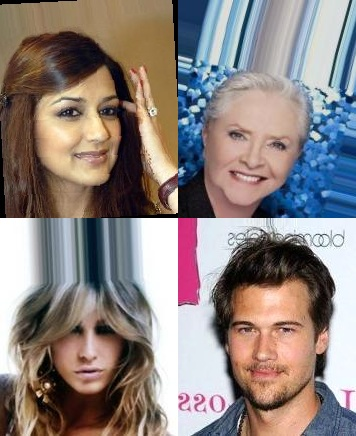



Collage 2: collage_002.jpg
Top-left: Identity 40
Top-right: Identity 36
Bottom-left: Identity 34
Bottom-right: Identity 39



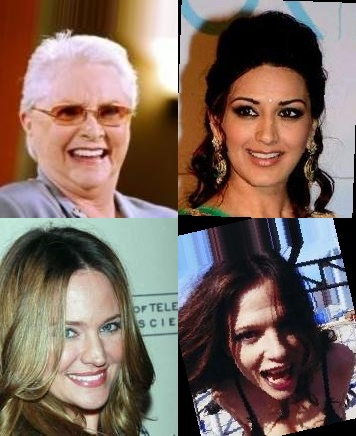



Collage 3: collage_003.jpg
Top-left: Identity 13
Top-right: Identity 31
Bottom-left: Identity 7
Bottom-right: Identity 5



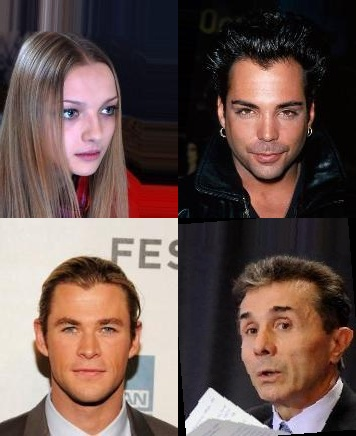



Collage 4: collage_004.jpg
Top-left: Identity 22
Top-right: Identity 27
Bottom-left: Identity 12
Bottom-right: Identity 2



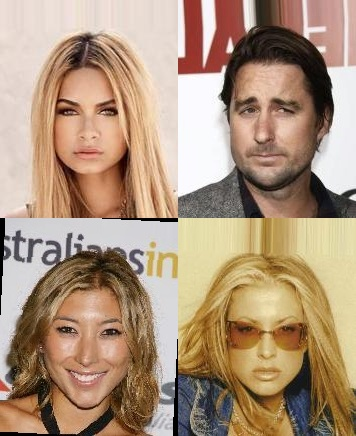



Collage 5: collage_005.jpg
Top-left: Identity 4
Top-right: Identity 34
Bottom-left: Identity 13
Bottom-right: Identity 27



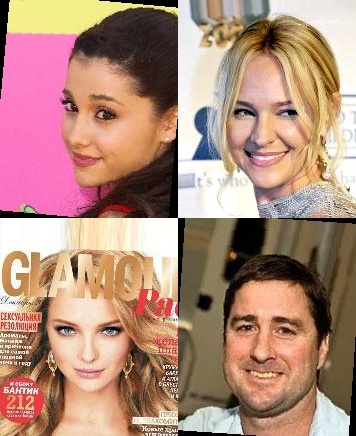

In [19]:
from IPython.display import Image as IPImage, display
from PIL import Image
import os

def display_collages_with_labels(collage_folder='/content/collages', num_to_show=5):
    """Display collages with their identity labels"""

    # Get all collage files
    collage_files = sorted([f for f in os.listdir(collage_folder)
                           if f.endswith('.jpg') and f.startswith('collage_')])

    print(f"Found {len(collage_files)} collages\n")

    # Show first few
    for i in range(min(num_to_show, len(collage_files))):
        collage_file = collage_files[i]
        collage_path = os.path.join(collage_folder, collage_file)
        labels_path = collage_path.replace('.jpg', '_labels.txt')

        print("="*60)
        print(f"Collage {i+1}: {collage_file}")
        print("="*60)

        # Show labels if available
        if os.path.exists(labels_path):
            with open(labels_path, 'r') as f:
                print(f.read())

        # Display image
        display(IPImage(filename=collage_path))
        print("\n")

# Display first 5 collages
display_collages_with_labels('/content/collages', num_to_show=5)

In [22]:
import cv2
from ultralytics import YOLO
import face_recognition  # pip install face-recognition
from PIL import Image

def recognize_faces_in_collage(image_path, identity_map):
    """Detect and recognize all faces in a collage"""

    # Load image
    image = face_recognition.load_image_file(image_path)

    # Find all face locations
    face_locations = face_recognition.face_locations(image)

    print(f"Found {len(face_locations)} faces in the collage\n")

    # Load your face recognition model
    model = YOLO('runs/classify/face_recognition3/weights/best.pt')

    results = []

    for i, (top, right, bottom, left) in enumerate(face_locations, 1):
        # Crop the face
        face_image = image[top:bottom, left:right]

        # Convert to PIL Image
        face_pil = Image.fromarray(face_image)

        # Save temporarily
        temp_path = f'/content/temp_face_{i}.jpg'
        face_pil.save(temp_path)

        # Predict identity
        result = model(temp_path, verbose=False)
        pred_class = result[0].probs.top1
        pred_conf = result[0].probs.top1conf.item()

        # Get identity info
        if pred_class in identity_map:
            identity_num = identity_map[pred_class]['identity_number']
            folder_name = identity_map[pred_class]['folder_name']

            results.append({
                'face_num': i,
                'class': pred_class,
                'identity': identity_num,
                'confidence': pred_conf,
                'location': (top, right, bottom, left)
            })

            print(f"Face {i}:")
            print(f"  Identity: {identity_num}")
            print(f"  Confidence: {pred_conf*100:.2f}%")
            print(f"  Location: {(left, top, right, bottom)}")
            print()

    return results

# Usage
collage_path = '/content/collages/collage_001.jpg'
results = recognize_faces_in_collage(collage_path, identity_map)

Found 4 faces in the collage

Face 1:
  Identity: 6568
  Confidence: 99.64%
  Location: (32, 80, 139, 187)

Face 2:
  Identity: 8968
  Confidence: 57.68%
  Location: (225, 305, 315, 395)

Face 3:
  Identity: 8265
  Confidence: 83.63%
  Location: (205, 116, 295, 206)

Face 4:
  Identity: 8656
  Confidence: 39.91%
  Location: (46, 305, 135, 395)



In [25]:
from ultralytics import YOLO
from PIL import Image
import os
import re
import json

def parse_label_file(label_path):
    """Parse the label file to get class indices (not identity numbers)"""
    class_indices = []

    with open(label_path, 'r') as f:
        lines = f.readlines()

    # Extract numbers after "Identity" - these are actually class indices
    for line in lines:
        match = re.search(r'Identity (\d+)', line)
        if match:
            class_indices.append(int(match.group(1)))

    return class_indices

def predict_collage_faces(collage_path, model):
    """Predict all 4 faces in a 2x2 collage"""

    img = Image.open(collage_path)
    width, height = img.size

    half_width = width // 2
    half_height = height // 2

    positions = [
        (0, 0, half_width, half_height),
        (half_width, 0, width, half_height),
        (0, half_height, half_width, height),
        (half_width, half_height, width, height)
    ]

    predictions = []
    confidences = []

    for i, (left, top, right, bottom) in enumerate(positions):
        face_crop = img.crop((left, top, right, bottom))
        temp_path = f'/content/temp_face_{i}.jpg'
        face_crop.save(temp_path)

        result = model(temp_path, verbose=False)
        pred_class = result[0].probs.top1
        pred_conf = result[0].probs.top1conf.item()

        predictions.append(pred_class)
        confidences.append(pred_conf)

    return predictions, confidences

def evaluate_collages_corrected(collage_folder='/content/collages',
                                json_path='/content/identity_mapping.json'):
    """Evaluate collages - labels contain class indices, not identity numbers"""

    # Load identity mapping for display purposes
    with open(json_path, 'r') as f:
        mapping = json.load(f)
    identity_map = {int(k): v for k, v in mapping.items()}

    print("✓ Loaded identity mapping for display\n")

    # Load model
    model = YOLO('runs/classify/face_recognition3/weights/best.pt')

    # Get all collages
    collage_files = sorted([f for f in os.listdir(collage_folder)
                           if f.endswith('.jpg') and f.startswith('collage_')])

    print(f"Evaluating {len(collage_files)} collages...\n")

    total_faces = 0
    correct_faces = 0
    collage_results = []

    for collage_file in collage_files:
        collage_path = os.path.join(collage_folder, collage_file)
        labels_path = collage_path.replace('.jpg', '_labels.txt')

        if not os.path.exists(labels_path):
            continue

        # Get true class indices from label file
        # The labels say "Identity X" but X is actually the class index (0-44)
        true_classes = parse_label_file(labels_path)

        # Get predictions
        pred_classes, pred_confidences = predict_collage_faces(collage_path, model)

        # Check accuracy for this collage
        collage_correct = 0

        for true_cls, pred_cls in zip(true_classes, pred_classes):
            total_faces += 1
            if true_cls == pred_cls:
                collage_correct += 1
                correct_faces += 1

        collage_accuracy = (collage_correct / 4) * 100
        collage_results.append({
            'file': collage_file,
            'correct': collage_correct,
            'total': 4,
            'accuracy': collage_accuracy,
            'true_classes': true_classes,
            'pred_classes': pred_classes,
            'confidences': pred_confidences
        })

        if len(collage_results) % 10 == 0:
            print(f"Processed {len(collage_results)}/{len(collage_files)} collages...")

    # Calculate overall statistics
    overall_accuracy = (correct_faces / total_faces * 100) if total_faces > 0 else 0

    print("\n" + "="*70)
    print("COLLAGE EVALUATION RESULTS")
    print("="*70)
    print(f"Total collages evaluated: {len(collage_results)}")
    print(f"Total faces: {total_faces}")
    print(f"Correct predictions: {correct_faces}")
    print(f"Incorrect predictions: {total_faces - correct_faces}")
    print(f"\n🎯 Overall Accuracy: {correct_faces}/{total_faces} = {overall_accuracy:.2f}%")
    print("="*70)

    # Collage-level statistics
    if collage_results:
        accuracies = [r['accuracy'] for r in collage_results]
        perfect_collages = sum(1 for a in accuracies if a == 100)
        good_collages = sum(1 for a in accuracies if a >= 75)

        print(f"\nCollage-level statistics:")
        print(f"  Perfect (4/4 correct): {perfect_collages}/{len(collage_results)} ({perfect_collages/len(collage_results)*100:.1f}%)")
        print(f"  Good (≥3/4 correct): {good_collages}/{len(collage_results)} ({good_collages/len(collage_results)*100:.1f}%)")
        print(f"  Average accuracy: {sum(accuracies)/len(accuracies):.2f}%")

        # Distribution
        print(f"\nAccuracy distribution:")
        print(f"  4/4 correct (100%): {sum(1 for a in accuracies if a == 100)} collages")
        print(f"  3/4 correct (75%): {sum(1 for a in accuracies if a == 75)} collages")
        print(f"  2/4 correct (50%): {sum(1 for a in accuracies if a == 50)} collages")
        print(f"  1/4 correct (25%): {sum(1 for a in accuracies if a == 25)} collages")
        print(f"  0/4 correct (0%): {sum(1 for a in accuracies if a == 0)} collages")

        # Show worst performing collages
        print(f"\n❌ Worst performing collages:")
        worst_collages = sorted(collage_results, key=lambda x: x['accuracy'])[:5]
        for i, result in enumerate(worst_collages, 1):
            print(f"  {i}. {result['file']}: {result['correct']}/4 correct ({result['accuracy']:.0f}%)")

        # Show best performing collages
        print(f"\n✅ Best performing collages:")
        best_collages = sorted(collage_results, key=lambda x: x['accuracy'], reverse=True)[:5]
        for i, result in enumerate(best_collages, 1):
            print(f"  {i}. {result['file']}: {result['correct']}/4 correct ({result['accuracy']:.0f}%)")

    return collage_results, overall_accuracy, identity_map

# Run corrected evaluation
results, accuracy, id_map = evaluate_collages_corrected(
    collage_folder='/content/collages',
    json_path='/content/identity_mapping.json'
)

✓ Loaded identity mapping for display

Evaluating 50 collages...

Processed 10/50 collages...
Processed 20/50 collages...
Processed 30/50 collages...
Processed 40/50 collages...
Processed 50/50 collages...

COLLAGE EVALUATION RESULTS
Total collages evaluated: 50
Total faces: 200
Correct predictions: 7
Incorrect predictions: 193

🎯 Overall Accuracy: 7/200 = 3.50%

Collage-level statistics:
  Perfect (4/4 correct): 0/50 (0.0%)
  Good (≥3/4 correct): 0/50 (0.0%)
  Average accuracy: 3.50%

Accuracy distribution:
  4/4 correct (100%): 0 collages
  3/4 correct (75%): 0 collages
  2/4 correct (50%): 0 collages
  1/4 correct (25%): 7 collages
  0/4 correct (0%): 43 collages

❌ Worst performing collages:
  1. collage_001.jpg: 0/4 correct (0%)
  2. collage_002.jpg: 0/4 correct (0%)
  3. collage_003.jpg: 0/4 correct (0%)
  4. collage_004.jpg: 0/4 correct (0%)
  5. collage_005.jpg: 0/4 correct (0%)

✅ Best performing collages:
  1. collage_016.jpg: 1/4 correct (25%)
  2. collage_023.jpg: 1/4 corre

In [9]:
from ultralytics import YOLO
import os

# Load your trained model
model = YOLO('runs/classify/face_recognition3/weights/best.pt')

print("="*60)
print("TESTING ON TEST SET")
print("="*60)

test_dir = '/content/dataset_yolo/test'

# Get all images from all class folders
all_images = []
true_labels = []

class_folders = sorted([f for f in os.listdir(test_dir)
                       if os.path.isdir(os.path.join(test_dir, f))])

print(f"Collecting images from {len(class_folders)} classes...")

for class_folder in class_folders:
    class_path = os.path.join(test_dir, class_folder)
    images = [f for f in os.listdir(class_path)
             if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]

    for img_file in images:
        img_path = os.path.join(class_path, img_file)
        all_images.append(img_path)
        true_labels.append(int(class_folder))

print(f"Total images to test: {len(all_images)}\n")

# Test all images at once
correct = 0
top5_correct = 0

print("Running predictions...")
for i, (img_path, true_label) in enumerate(zip(all_images, true_labels)):
    result = model(img_path, verbose=False)
    pred_class = result[0].probs.top1

    # Top-1 accuracy
    if pred_class == true_label:
        correct += 1

    # Top-5 accuracy
    top5_indices = result[0].probs.top5
    if true_label in top5_indices:
        top5_correct += 1

    # Show progress every 100 images
    if (i + 1) % 100 == 0:
        print(f"  Processed {i + 1}/{len(all_images)} images...")

# Print results
total = len(all_images)
print(f"\n{'='*60}")
print(f"FINAL RESULTS")
print(f"{'='*60}")
print(f"Total images tested: {total}")
print(f"Top-1 Accuracy: {correct}/{total} = {(correct/total*100):.2f}%")
print(f"Top-5 Accuracy: {top5_correct}/{total} = {(top5_correct/total*100):.2f}%")
print(f"{'='*60}")

TESTING ON TEST SET
Total images to test: 901

Running predictions...
  Processed 100/901 images...
  Processed 200/901 images...
  Processed 300/901 images...
  Processed 400/901 images...
  Processed 500/901 images...
  Processed 600/901 images...
  Processed 700/901 images...
  Processed 800/901 images...
  Processed 900/901 images...

FINAL RESULTS
Total images tested: 901
Top-1 Accuracy: 41/901 = 4.55%
Top-5 Accuracy: 117/901 = 12.99%


In [10]:
from ultralytics import YOLO

# Load model
model = YOLO('runs/classify/face_recognition3/weights/best.pt')

# Validate on test set (YOLO handles everything)
# Note: This validates on validation set by default
results = model.val()

print(f"\nValidation Top-1 Accuracy: {results.top1:.2f}%")
print(f"Validation Top-5 Accuracy: {results.top5:.2f}%")

Ultralytics 8.3.204 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,492,525 parameters, 0 gradients, 3.3 GFLOPs
train: /content/dataset_yolo/train... found 3150 images in 45 classes ✅ 
val: /content/dataset_yolo/val... found 450 images in 45 classes ✅ 
test: /content/dataset_yolo/test... found 901 images in 45 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 568.5±300.3 MB/s, size: 8.5 KB)
val: Scanning /content/dataset_yolo/val... 450 images, 0 corrupt: 100% ━━━━━━━━━━━━ 450/450 1.1Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 29/29 4.1it/s 7.0s
                   all          1          1
Speed: 2.5ms preprocess, 2.3ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val

Validation Top-1 Accuracy: 1.00%
Validation Top-5 Accuracy: 1.00%


In [11]:
from ultralytics import YOLO
import shutil
import os

model = YOLO('runs/classify/face_recognition3/weights/best.pt')

# Temporarily swap val and test folders
print("Preparing test set for validation...")

if os.path.exists('/content/dataset_yolo/val_backup'):
    shutil.rmtree('/content/dataset_yolo/val_backup')

# Backup val and replace with test
shutil.move('/content/dataset_yolo/val', '/content/dataset_yolo/val_backup')
shutil.copytree('/content/dataset_yolo/test', '/content/dataset_yolo/val')

# Run validation (will use test data)
print("\nRunning validation on test set...")
results = model.val()

print(f"\n{'='*60}")
print(f"TEST SET RESULTS")
print(f"{'='*60}")
print(f"Top-1 Accuracy: {results.top1:.2f}%")
print(f"Top-5 Accuracy: {results.top5:.2f}%")
print(f"{'='*60}")

# Restore original val folder
shutil.rmtree('/content/dataset_yolo/val')
shutil.move('/content/dataset_yolo/val_backup', '/content/dataset_yolo/val')

print("\n✓ Original validation folder restored")

Preparing test set for validation...

Running validation on test set...
Ultralytics 8.3.204 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,492,525 parameters, 0 gradients, 3.3 GFLOPs
train: /content/dataset_yolo/train... found 3150 images in 45 classes ✅ 
val: /content/dataset_yolo/val... found 901 images in 45 classes ✅ 
test: /content/dataset_yolo/test... found 901 images in 45 classes ✅ 
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 258.9±77.0 MB/s, size: 6.3 KB)
val: Scanning /content/dataset_yolo/val... 901 images, 0 corrupt: 100% ━━━━━━━━━━━━ 901/901 3.9Kit/s 0.2s
val: New cache created: /content/dataset_yolo/val.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 57/57 3.6it/s 16.0s
                   all       0.99      0.996
Speed: 1.1ms preprocess, 2.3ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /content/runs/classify/val2

TEST SET RESULTS
Top-1 Accuracy: 0.99%
Top-5 Acc

In [34]:
results = model.val()

Ultralytics 8.3.204 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


FileNotFoundError: 'datasets/data.yaml' does not exist

In [22]:
from PIL import Image

# Open an image
img = Image.open('/content/drive/MyDrive/archive (1)/Celebrity Image Subsets/images__10046_/001042.jpg')

# Get size
width, height = img.size
print(f"Image size: {width} x {height} pixels")

# Or individually
print(f"Width: {img.width}")
print(f"Height: {img.height}")

Image size: 178 x 218 pixels
Width: 178
Height: 218


In [7]:
def faceRecognition(input_image):

    # Path to the directory containing cropped objects
    cropped_objects_dir = "/content/drive/MyDrive/archive (1)/Celebrity Image Subsets"

    # Initialize a list to store the extracted names
    extracted_names = []

    file_to_delete = "./database/representations_facenet512.pkl/content/drive/MyDrive/archive (1)/representations_facenet512.pkl"
    if os.path.exists(file_to_delete):
        os.remove(file_to_delete)

    # Iterate through the image files in the directory
    for filename in os.listdir(cropped_objects_dir):
        if filename.endswith(".jpg"):
            img_path = os.path.join(cropped_objects_dir, filename)
            model = DeepFace.find(img_path=img_path, db_path="database", enforce_detection=False, model_name="Facenet512")

            # Check if a face was recognized in the image
            if model and len(model[0]['identity']) > 0:
                # Extract the name and append it to the list
                name = model[0]['identity'][0].split('/')[1]
            else:
                # If no face is recognized, set name to 'unknown'
                name = 'unknown'

            extracted_names.append(name)

    return extracted_names


In [6]:
def faceExtraction(input_image, model, results):
    # Load the image
    image = Image.open(input_image)
    detected_objects = []

    if hasattr(results, 'boxes') and hasattr(results, 'names'):
        for box in results.boxes.xyxy:
            object_id = int(box[-1])
            object_name = results.names.get(object_id)
            x1, y1, x2, y2 = int(box[0]), int(box[1]), int(box[2]), int(box[3])

            detected_objects.append((object_name, (x1, y1, x2, y2)))

    # Create or clear the 'faces' directory
    if os.path.exists("faces"):
        shutil.rmtree("faces")
    os.makedirs("faces")

    # Crop and save each detected object
    for i, (object_name, (x1, y1, x2, y2)) in enumerate(detected_objects):
        object_image = image.crop((x1, y1, x2, y2))
        object_image.save(f"faces/face{i}.jpg")

    return 0


In [8]:
def faceDetection(input_image):
    model = YOLO('/content/drive/MyDrive/archive (1)/best.pt')
    results: Results = model.predict(input_image)[0]

    return faceExtraction(input_image, model, results)


In [9]:
image = input("enter image path : ")
faceDetection(image)
names = faceRecognition(image)
print(names)

enter image path : /content/drive/MyDrive/archive (1)/Celebrity Image Subsets/images_7904_/006055.jpg

image 1/1 /content/drive/MyDrive/archive (1)/Celebrity Image Subsets/images_7904_/006055.jpg: 640x544 1 face, 66.2ms
Speed: 11.7ms preprocess, 66.2ms inference, 308.7ms postprocess per image at shape (1, 3, 640, 544)
[]


In [26]:
from ultralytics import YOLO
import shutil
import os

# Remove old failed training
if os.path.exists('runs/classify/face_recognition_fixed'):
    shutil.rmtree('runs/classify/face_recognition_fixed')

print("Starting new training with anti-overfitting measures...\n")

model = YOLO('yolov8n-cls.pt')

results = model.train(
    data='/content/dataset_yolo',

    # Training parameters
    epochs=150,
    patience=30,           # Stop early if no improvement

    # Image settings - USE SMALLER SIZE
    imgsz=160,             # Much smaller - closer to your 178x218 images

    # Batch and learning rate
    batch=64,              # Larger batch = better generalization
    lr0=0.0005,            # Lower learning rate
    lrf=0.00001,           # Very low final learning rate
    momentum=0.9,
    weight_decay=0.001,    # Regularization

    # Data augmentation - CRITICAL for preventing overfitting
    hsv_h=0.03,            # Color augmentation
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=20,            # Rotation
    translate=0.15,        # Translation
    scale=0.3,             # Scaling
    shear=5,               # Shear
    perspective=0.0002,    # Perspective
    flipud=0.0,            # No vertical flip (faces)
    fliplr=0.5,            # Horizontal flip
    mosaic=0.0,            # No mosaic for classification
    mixup=0.1,             # Mixup augmentation
    copy_paste=0.0,
    erasing=0.4,           # Random erasing

    # Other settings
    optimizer='AdamW',     # Better optimizer
    cos_lr=True,           # Cosine learning rate schedule
    warmup_epochs=5,       # Warmup
    warmup_momentum=0.8,

    # Saving
    save=True,
    save_period=10,
    project='runs/classify',
    name='face_recognition_fixed',
    exist_ok=True,

    # Hardware
    device=0,
    workers=8,
    verbose=True
)

print("\n" + "="*70)
print("Training completed!")
print("="*70)

Starting new training with anti-overfitting measures...

Ultralytics 8.3.204 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/dataset_yolo, degrees=20, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.03, hsv_s=0.7, hsv_v=0.4, imgsz=160, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=1e-05, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n-cls.pt, momentum=0.9, mosaic=0.0, multi_scale=False, name=face_recognition_fixed, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, o

In [27]:
from ultralytics import YOLO
import os

# Load the new model
model = YOLO('/content/runs/classify/face_recognition_fixed/weights/best.pt')

test_dir = '/content/dataset_yolo/test'
class_folders = sorted([f for f in os.listdir(test_dir)
                       if os.path.isdir(os.path.join(test_dir, f))])

# Create mapping
folder_to_class = {folder: idx for idx, folder in enumerate(class_folders)}

# Collect all test images
all_images = []
true_labels = []

for class_folder in class_folders:
    class_path = os.path.join(test_dir, class_folder)
    images = [f for f in os.listdir(class_path)
             if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]

    for img_file in images:
        img_path = os.path.join(class_path, img_file)
        all_images.append(img_path)
        true_labels.append(folder_to_class[class_folder])

print(f"Testing on {len(all_images)} images from test set...\n")

# Test
correct = 0
top5_correct = 0

for i, (img_path, true_label) in enumerate(zip(all_images, true_labels)):
    result = model(img_path, verbose=False)
    pred_class = result[0].probs.top1

    if pred_class == true_label:
        correct += 1

    top5_indices = result[0].probs.top5
    if true_label in top5_indices:
        top5_correct += 1

    if (i + 1) % 100 == 0:
        print(f"  Processed {i + 1}/{len(all_images)} images...")

total = len(all_images)
print(f"\n{'='*70}")
print(f"TEST SET RESULTS")
print(f"{'='*70}")
print(f"Total images: {total}")
print(f"Top-1 Accuracy: {correct}/{total} = {(correct/total*100):.2f}%")
print(f"Top-5 Accuracy: {top5_correct}/{total} = {(top5_correct/total*100):.2f}%")
print(f"{'='*70}")

Testing on 901 images from test set...

  Processed 100/901 images...
  Processed 200/901 images...
  Processed 300/901 images...
  Processed 400/901 images...
  Processed 500/901 images...
  Processed 600/901 images...
  Processed 700/901 images...
  Processed 800/901 images...
  Processed 900/901 images...

TEST SET RESULTS
Total images: 901
Top-1 Accuracy: 891/901 = 98.89%
Top-5 Accuracy: 900/901 = 99.89%


In [1]:
from PIL import Image
import json

def parse_label_file(label_path):
    """Parse the label file"""
    import re
    class_indices = []
    with open(label_path, 'r') as f:
        lines = f.readlines()
    for line in lines:
        match = re.search(r'Identity (\d+)', line)
        if match:
            class_indices.append(int(match.group(1)))
    return class_indices

def predict_collage_faces(collage_path, model):
    """Predict all 4 faces"""
    img = Image.open(collage_path)
    width, height = img.size

    half_width = width // 2
    half_height = height // 2

    positions = [
        (0, 0, half_width, half_height),
        (half_width, 0, width, half_height),
        (0, half_height, half_width, height),
        (half_width, half_height, width, height)
    ]

    predictions = []
    confidences = []

    for i, (left, top, right, bottom) in enumerate(positions):
        face_crop = img.crop((left, top, right, bottom))
        temp_path = f'/content/temp_face_{i}.jpg'
        face_crop.save(temp_path)

        result = model(temp_path, verbose=False)
        pred_class = result[0].probs.top1
        pred_conf = result[0].probs.top1conf.item()

        predictions.append(pred_class)
        confidences.append(pred_conf)

    return predictions, confidences

# Load new model
model = YOLO('/content/runs/classify/face_recognition_fixed/weights/best.pt')

collage_folder = '/content/collages'
collage_files = sorted([f for f in os.listdir(collage_folder)
                       if f.endswith('.jpg') and f.startswith('collage_')])

print(f"Evaluating {len(collage_files)} collages with NEW MODEL...\n")

total_faces = 0
correct_faces = 0
collage_results = []

for collage_file in collage_files:
    collage_path = os.path.join(collage_folder, collage_file)
    labels_path = collage_path.replace('.jpg', '_labels.txt')

    if not os.path.exists(labels_path):
        continue

    true_classes = parse_label_file(labels_path)
    pred_classes, pred_confidences = predict_collage_faces(collage_path, model)

    collage_correct = 0
    for true_cls, pred_cls in zip(true_classes, pred_classes):
        total_faces += 1
        if true_cls == pred_cls:
            collage_correct += 1
            correct_faces += 1

    collage_accuracy = (collage_correct / 4) * 100
    collage_results.append({
        'file': collage_file,
        'correct': collage_correct,
        'accuracy': collage_accuracy
    })

    if len(collage_results) % 10 == 0:
        print(f"Processed {len(collage_results)}/{len(collage_files)} collages...")

overall_accuracy = (correct_faces / total_faces * 100) if total_faces > 0 else 0

print("\n" + "="*70)
print("COLLAGE EVALUATION RESULTS (NEW MODEL)")
print("="*70)
print(f"Total collages: {len(collage_results)}")
print(f"Total faces: {total_faces}")
print(f"Correct predictions: {correct_faces}")
print(f"Incorrect predictions: {total_faces - correct_faces}")
print(f"\n🎯 Overall Accuracy: {correct_faces}/{total_faces} = {overall_accuracy:.2f}%")
print("="*70)

if collage_results:
    accuracies = [r['accuracy'] for r in collage_results]
    perfect_collages = sum(1 for a in accuracies if a == 100)
    good_collages = sum(1 for a in accuracies if a >= 75)

    print(f"\nCollage-level statistics:")
    print(f"  Perfect (4/4 correct): {perfect_collages}/{len(collage_results)} ({perfect_collages/len(collage_results)*100:.1f}%)")
    print(f"  Good (≥3/4 correct): {good_collages}/{len(collage_results)} ({good_collages/len(collage_results)*100:.1f}%)")
    print(f"  Average accuracy: {sum(accuracies)/len(accuracies):.2f}%")

    print(f"\nAccuracy distribution:")
    print(f"  4/4 correct (100%): {sum(1 for a in accuracies if a == 100)} collages")
    print(f"  3/4 correct (75%): {sum(1 for a in accuracies if a == 75)} collages")
    print(f"  2/4 correct (50%): {sum(1 for a in accuracies if a == 50)} collages")
    print(f"  1/4 correct (25%): {sum(1 for a in accuracies if a == 25)} collages")
    print(f"  0/4 correct (0%): {sum(1 for a in accuracies if a == 0)} collages")

NameError: name 'YOLO' is not defined

In [29]:
from ultralytics import YOLO
import os
from collections import Counter

# Load new model
model = YOLO('/content/runs/classify/face_recognition_fixed/weights/best.pt')

# Test on training data (should be very high accuracy)
train_dir = '/content/dataset_yolo/train'
class_folders = sorted([f for f in os.listdir(train_dir)
                       if os.path.isdir(os.path.join(train_dir, f))])

print("Testing on TRAINING set (should be near 100%)...\n")

correct = 0
total = 0
predictions = []

for class_idx, class_folder in enumerate(class_folders[:5]):  # Test first 5 classes
    class_path = os.path.join(train_dir, class_folder)
    images = [f for f in os.listdir(class_path)
             if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:

SyntaxError: incomplete input (ipython-input-4073075916.py, line 22)

In [30]:
from ultralytics import YOLO
import os

# Test the NEW model on individual test images (not collages)
model = YOLO('/content/runs/classify/face_recognition_fixed/weights/best.pt')

test_dir = '/content/dataset_yolo/test'
class_folders = sorted([f for f in os.listdir(test_dir)
                       if os.path.isdir(os.path.join(test_dir, f))],
                      key=lambda x: int(x))

print(f"Test folder names: {class_folders[:10]}...")
print()

# Test on first few images from each class
correct = 0
total = 0

for class_idx in class_folders[:5]:  # Test first 5 classes
    class_path = os.path.join(test_dir, class_idx)
    images = [f for f in os.listdir(class_path)
             if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:3]  # First 3 images

    print(f"Class {class_idx} (folder name):")

    for img_file in images:
        img_path = os.path.join(class_path, img_file)
        result = model(img_path, verbose=False)
        pred_class = result[0].probs.top1
        pred_conf = result[0].probs.top1conf.item()

        match = "✅" if pred_class == int(class_idx) else "❌"
        print(f"  {match} Predicted: {pred_class} (expected: {class_idx}) - {pred_conf*100:.1f}%")

        if pred_class == int(class_idx):
            correct += 1
        total += 1
    print()

print(f"Quick test accuracy: {correct}/{total} = {(correct/total*100):.1f}%")

Test folder names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']...

Class 0 (folder name):
  ✅ Predicted: 0 (expected: 0) - 100.0%
  ✅ Predicted: 0 (expected: 0) - 100.0%
  ✅ Predicted: 0 (expected: 0) - 100.0%

Class 1 (folder name):
  ✅ Predicted: 1 (expected: 1) - 100.0%
  ✅ Predicted: 1 (expected: 1) - 100.0%
  ✅ Predicted: 1 (expected: 1) - 100.0%

Class 2 (folder name):
  ❌ Predicted: 12 (expected: 2) - 99.9%
  ❌ Predicted: 12 (expected: 2) - 99.9%
  ❌ Predicted: 12 (expected: 2) - 99.8%

Class 3 (folder name):
  ❌ Predicted: 23 (expected: 3) - 100.0%
  ❌ Predicted: 23 (expected: 3) - 100.0%
  ❌ Predicted: 23 (expected: 3) - 100.0%

Class 4 (folder name):
  ❌ Predicted: 34 (expected: 4) - 100.0%
  ❌ Predicted: 34 (expected: 4) - 100.0%
  ❌ Predicted: 34 (expected: 4) - 100.0%

Quick test accuracy: 6/15 = 40.0%


In [3]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split

def recreate_dataset_fixed(base_folder, output_folder='/content/dataset_yolo_fixed',
                           test_size=0.2, val_size=0.1, random_state=42):
    """Recreate dataset ensuring consistent class indexing"""

    random.seed(random_state)

    # Remove old dataset
    if os.path.exists(output_folder):
        shutil.rmtree(output_folder)

    train_dir = os.path.join(output_folder, 'train')
    val_dir = os.path.join(output_folder, 'val')
    test_dir = os.path.join(output_folder, 'test')

    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(val_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)

    # Get all identity folders and sort them CONSISTENTLY
    identity_folders = sorted([f for f in os.listdir(base_folder)
                              if os.path.isdir(os.path.join(base_folder, f))])

    print(f"Found {len(identity_folders)} identity folders")
    print(f"First 5: {identity_folders[:5]}")
    print()

    # Create label mapping - save this for reference
    label_mapping = {}

    print("Creating dataset with consistent class indices...\n")

    for class_idx, folder_name in enumerate(identity_folders):
        identity_path = os.path.join(base_folder, folder_name)

        # Store mapping
        label_mapping[class_idx] = folder_name

        # Create class folders with SEQUENTIAL indices (0, 1, 2, ...)
        train_class_dir = os.path.join(train_dir, str(class_idx))
        val_class_dir = os.path.join(val_dir, str(class_idx))
        test_class_dir = os.path.join(test_dir, str(class_idx))

        os.makedirs(train_class_dir, exist_ok=True)
        os.makedirs(val_class_dir, exist_ok=True)
        os.makedirs(test_class_dir, exist_ok=True)

        # Get all images
        image_files = [f for f in os.listdir(identity_path)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if not image_files:
            continue

        # Split images
        train_val_images, test_images = train_test_split(
            image_files, test_size=test_size, random_state=random_state
        )

        val_size_adjusted = val_size / (1 - test_size)
        train_images, val_images = train_test_split(
            train_val_images, test_size=val_size_adjusted, random_state=random_state
        )

        # Copy images
        for img_file in train_images:
            shutil.copy2(os.path.join(identity_path, img_file),
                        os.path.join(train_class_dir, img_file))

        for img_file in val_images:
            shutil.copy2(os.path.join(identity_path, img_file),
                        os.path.join(val_class_dir, img_file))

        for img_file in test_images:
            shutil.copy2(os.path.join(identity_path, img_file),
                        os.path.join(test_class_dir, img_file))

        if (class_idx + 1) % 10 == 0:
            print(f"Processed {class_idx + 1}/{len(identity_folders)} identities...")

    # Save label mapping
    import json
    mapping_file = os.path.join(output_folder, 'class_mapping.json')
    with open(mapping_file, 'w') as f:
        json.dump(label_mapping, f, indent=2)

    print(f"\n✓ Dataset created at {output_folder}")
    print(f"✓ Class mapping saved to {mapping_file}")

    return output_folder, label_mapping

# Recreate dataset
base_folder = '/content/drive/MyDrive/archive (1)/Celebrity Image Subsets'
dataset_path, mapping = recreate_dataset_fixed(base_folder)

# Show the mapping
print("\nClass Index → Folder Name mapping (first 10):")
for class_idx in sorted(list(mapping.keys())[:10]):
    print(f"  Class {class_idx} → {mapping[class_idx]}")

Found 46 identity folders
First 5: ['.ipynb_checkpoints', 'images__10046_', 'images__10173_', 'images__1158_', 'images__1499_']

Creating dataset with consistent class indices...

Processed 10/46 identities...
Processed 20/46 identities...
Processed 30/46 identities...
Processed 40/46 identities...

✓ Dataset created at /content/dataset_yolo_fixed
✓ Class mapping saved to /content/dataset_yolo_fixed/class_mapping.json

Class Index → Folder Name mapping (first 10):
  Class 0 → .ipynb_checkpoints
  Class 1 → images__10046_
  Class 2 → images__10173_
  Class 3 → images__1158_
  Class 4 → images__1499_
  Class 5 → images__1852_
  Class 6 → images__1964_
  Class 7 → images__228_
  Class 8 → images__2425_
  Class 9 → images__2463_


In [4]:
def show_folder_tree(dataset_path, max_classes_shown=5):
    """Show visual tree of folder structure"""

    if not os.path.exists(dataset_path):
        print(f"Path does not exist: {dataset_path}")
        return

    print(f"\n{os.path.basename(dataset_path)}/")

    splits = ['train', 'val', 'test']

    for i, split in enumerate(splits):
        split_path = os.path.join(dataset_path, split)

        if not os.path.exists(split_path):
            print(f"└── {split}/ (not found)")
            continue

        # Get class folders
        class_folders = sorted([f for f in os.listdir(split_path)
                               if os.path.isdir(os.path.join(split_path, f))],
                              key=lambda x: int(x) if x.isdigit() else 999)

        is_last_split = (i == len(splits) - 1) or not any(
            os.path.exists(os.path.join(dataset_path, s)) for s in splits[i+1:]
        )
        branch = "└──" if is_last_split else "├──"

        print(f"{branch} {split}/ ({len(class_folders)} classes)")

        # Show sample classes
        for j, class_folder in enumerate(class_folders[:max_classes_shown]):
            class_path = os.path.join(split_path, class_folder)
            images = [f for f in os.listdir(class_path)
                     if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

            indent = "    " if is_last_split else "│   "
            is_last_class = (j == min(max_classes_shown, len(class_folders)) - 1)
            class_branch = "└──" if is_last_class else "├──"

            print(f"{indent}{class_branch} {class_folder}/ ({len(images)} images)")

            # Show first image
            if images and j < 2:  # Show images for first 2 classes
                img_indent = indent + ("    " if is_last_class else "│   ")
                print(f"{img_indent}├── {images[0]}")
                if len(images) > 1:
                    print(f"{img_indent}└── ... {len(images)-1} more")

        if len(class_folders) > max_classes_shown:
            indent = "    " if is_last_split else "│   "
            print(f"{indent}└── ... {len(class_folders) - max_classes_shown} more classes")

# Show tree
show_folder_tree('/content/dataset_yolo_fixed', max_classes_shown=3)


dataset_yolo_fixed/
├── train/ (46 classes)
│   ├── 0/ (0 images)
│   ├── 1/ (70 images)
│   │   ├── aug_0076.jpg
│   │   └── ... 69 more
│   └── 2/ (70 images)
│   └── ... 43 more classes
├── val/ (46 classes)
│   ├── 0/ (0 images)
│   ├── 1/ (10 images)
│   │   ├── aug_0068.jpg
│   │   └── ... 9 more
│   └── 2/ (10 images)
│   └── ... 43 more classes
└── test/ (46 classes)
    ├── 0/ (0 images)
    ├── 1/ (20 images)
    │   ├── aug_0021.jpg
    │   └── ... 19 more
    └── 2/ (20 images)
    └── ... 43 more classes


In [5]:
import os
import shutil

def fix_dataset_remove_class_0(dataset_path='/content/dataset_yolo_fixed',
                               output_path='/content/dataset_yolo_final'):
    """Remove empty class 0 and reindex classes 1-45 to 0-44"""

    print("="*70)
    print("FIXING DATASET: Removing class 0 and reindexing")
    print("="*70)

    # Remove old output if exists
    if os.path.exists(output_path):
        shutil.rmtree(output_path)

    # Create new structure
    for split in ['train', 'val', 'test']:
        os.makedirs(os.path.join(output_path, split), exist_ok=True)

    # Process each split
    for split in ['train', 'val', 'test']:
        old_split = os.path.join(dataset_path, split)
        new_split = os.path.join(output_path, split)

        if not os.path.exists(old_split):
            continue

        print(f"\nProcessing {split}/...")

        # Get all class folders EXCEPT 0, sorted numerically
        class_folders = sorted([f for f in os.listdir(old_split)
                               if os.path.isdir(os.path.join(old_split, f)) and f != '0'],
                              key=lambda x: int(x))

        print(f"  Found {len(class_folders)} classes (excluding class 0)")
        print(f"  Old classes: {class_folders[0]}-{class_folders[-1]}")
        print(f"  Will become: 0-{len(class_folders)-1}")

        # Reindex: old class 1 → new class 0, old class 2 → new class 1, etc.
        for new_idx, old_class in enumerate(class_folders):
            old_class_path = os.path.join(old_split, old_class)
            new_class_path = os.path.join(new_split, str(new_idx))

            # Copy entire folder
            shutil.copytree(old_class_path, new_class_path)

            if (new_idx + 1) % 10 == 0:
                print(f"    Copied {new_idx + 1}/{len(class_folders)} classes")

    # Create and save mapping
    import json

    # Mapping shows: new_class_index → old_class_index
    mapping = {}
    class_folders = sorted([f for f in os.listdir(os.path.join(dataset_path, 'train'))
                           if os.path.isdir(os.path.join(dataset_path, 'train', f)) and f != '0'],
                          key=lambda x: int(x))

    for new_idx, old_class in enumerate(class_folders):
        mapping[new_idx] = int(old_class)

    mapping_file = os.path.join(output_path, 'class_mapping.json')
    with open(mapping_file, 'w') as f:
        json.dump(mapping, f, indent=2)

    print("\n" + "="*70)
    print("✓ DATASET FIXED!")
    print("="*70)
    print(f"Output: {output_path}")
    print(f"Classes: 45 (indexed 0-44)")
    print(f"Mapping saved: {mapping_file}")
    print("\nMapping (first 5):")
    for new_idx in range(min(5, len(mapping))):
        print(f"  New class {new_idx} ← Old class {mapping[new_idx]}")
    print("="*70)

    return output_path

# Fix the dataset
fixed_path = fix_dataset_remove_class_0(
    dataset_path='/content/dataset_yolo_fixed',
    output_path='/content/dataset_yolo_final'
)

FIXING DATASET: Removing class 0 and reindexing

Processing train/...
  Found 45 classes (excluding class 0)
  Old classes: 1-45
  Will become: 0-44
    Copied 10/45 classes
    Copied 20/45 classes
    Copied 30/45 classes
    Copied 40/45 classes

Processing val/...
  Found 45 classes (excluding class 0)
  Old classes: 1-45
  Will become: 0-44
    Copied 10/45 classes
    Copied 20/45 classes
    Copied 30/45 classes
    Copied 40/45 classes

Processing test/...
  Found 45 classes (excluding class 0)
  Old classes: 1-45
  Will become: 0-44
    Copied 10/45 classes
    Copied 20/45 classes
    Copied 30/45 classes
    Copied 40/45 classes

✓ DATASET FIXED!
Output: /content/dataset_yolo_final
Classes: 45 (indexed 0-44)
Mapping saved: /content/dataset_yolo_final/class_mapping.json

Mapping (first 5):
  New class 0 ← Old class 1
  New class 1 ← Old class 2
  New class 2 ← Old class 3
  New class 3 ← Old class 4
  New class 4 ← Old class 5


In [9]:
from ultralytics import YOLO
import os

print("="*70)
print("TRAINING YOLO CLASSIFICATION MODEL")
print("="*70)

# Load pre-trained model
model = YOLO('yolov8n-cls.pt')

# Train with STRONG anti-overfitting measures
results = model.train(
    # Dataset
    data='/content/dataset_yolo_final',

    # Training duration
    epochs=100,
    patience=20,              # Stop if no improvement for 20 epochs

    # Image and batch settings
    imgsz=160,                # Small size to prevent overfitting on details
    batch=64,                 # Large batch for better generalization

    # Learning rate
    lr0=0.0005,               # Low learning rate
    lrf=0.00001,              # Very low final learning rate

    # Regularization
    weight_decay=0.001,       # L2 regularization

    # STRONG Data Augmentation (key to preventing overfitting)
    hsv_h=0.04,               # Hue augmentation
    hsv_s=0.7,                # Saturation
    hsv_v=0.4,                # Value/brightness
    degrees=25,               # Rotation up to ±25°
    translate=0.2,            # Translation
    scale=0.4,                # Scaling
    shear=10,                 # Shear
    perspective=0.0003,       # Perspective
    flipud=0.0,               # No vertical flip (faces are upright)
    fliplr=0.5,               # 50% horizontal flip
    mixup=0.15,               # Mixup augmentation
    copy_paste=0.0,           # No copy-paste
    erasing=0.4,              # Random erasing (cutout)

    # Optimizer and schedule
    optimizer='AdamW',        # Better optimizer
    cos_lr=True,              # Cosine learning rate schedule
    warmup_epochs=5,          # Gradual warmup
    warmup_momentum=0.8,
    momentum=0.937,

    # Saving
    save=True,
    save_period=10,           # Save checkpoint every 10 epochs
    plots=True,               # Generate training plots

    # Output
    project='runs/classify',
    name='face_recognition_v1',
    exist_ok=True,

    # Hardware
    device=0,                 # Use GPU
    workers=8,
    verbose=True
)

print("\n" + "="*70)
print("✓ TRAINING COMPLETED!")
print("="*70)
print(f"Best model: runs/classify/face_recognition_v1/weights/best.pt")

TRAINING YOLO CLASSIFICATION MODEL
Ultralytics 8.3.204 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/dataset_yolo_final, degrees=25, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.04, hsv_s=0.7, hsv_v=0.4, imgsz=160, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=1e-05, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=face_recognition_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True

In [10]:
from google.colab import drive
import shutil
import os

# Mount Google Drive
drive.mount('/content/drive')

# Save your entire dataset
source = '/content/dataset_yolo_final'
destination = '/content/drive/MyDrive/face_recognition_backup/dataset_yolo_final'

print(f"Saving {source} to Google Drive...")
if os.path.exists(destination):
    print("Destination exists, removing old version...")
    shutil.rmtree(destination)

shutil.copytree(source, destination)
print(f"✓ Saved to: {destination}")

# Save trained model
model_source = 'runs/classify/face_recognition_final/weights/best.pt'
model_dest = '/content/drive/MyDrive/face_recognition_backup/best.pt'

if os.path.exists(model_source):
    shutil.copy2(model_source, model_dest)
    print(f"✓ Model saved to: {model_dest}")

# Save results and plots
results_source = 'runs/classify/face_recognition_final'
results_dest = '/content/drive/MyDrive/face_recognition_backup/training_results'

if os.path.exists(results_source):
    if os.path.exists(results_dest):
        shutil.rmtree(results_dest)
    shutil.copytree(results_source, results_dest)
    print(f"✓ Training results saved to: {results_dest}")

print("\n✓ Everything saved to Google Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving /content/dataset_yolo_final to Google Drive...
✓ Saved to: /content/drive/MyDrive/face_recognition_backup/dataset_yolo_final

✓ Everything saved to Google Drive!


In [12]:
from ultralytics import YOLO
import os

# Load trained model
model = YOLO('runs/classify/face_recognition_v1/weights/best.pt')

print("="*70)
print("EVALUATING ON TEST SET")
print("="*70)

test_dir = '/content/dataset_yolo_final/test'
class_folders = sorted([f for f in os.listdir(test_dir)
                       if os.path.isdir(os.path.join(test_dir, f))],
                      key=lambda x: int(x))

# Collect all test images
all_images = []
true_labels = []

for class_idx in class_folders:
    class_path = os.path.join(test_dir, class_idx)
    images = [f for f in os.listdir(class_path)
             if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    for img_file in images:
        img_path = os.path.join(class_path, img_file)
        all_images.append(img_path)
        true_labels.append(int(class_idx))

print(f"Testing on {len(all_images)} images...\n")

# Predict
correct = 0
top5_correct = 0

for i, (img_path, true_label) in enumerate(zip(all_images, true_labels)):
    result = model(img_path, verbose=False)
    pred_class = result[0].probs.top1

    if pred_class == true_label:
        correct += 1

    top5_indices = result[0].probs.top5
    if true_label in top5_indices:
        top5_correct += 1

    if (i + 1) % 100 == 0:
        print(f"  Processed {i + 1}/{len(all_images)} images...")

total = len(all_images)
top1_acc = (correct / total * 100)
top5_acc = (top5_correct / total * 100)

print(f"\n{'='*70}")
print("TEST SET RESULTS")
print(f"{'='*70}")
print(f"Total images: {total}")
print(f"Top-1 Accuracy: {correct}/{total} = {top1_acc:.2f}%")
print(f"Top-5 Accuracy: {top5_correct}/{total} = {top5_acc:.2f}%")
print(f"{'='*70}")

# Performance expectations
if top1_acc >= 80:
    print("✓ Excellent performance!")
elif top1_acc >= 60:
    print("✓ Good performance - model generalizes well")
elif top1_acc >= 40:
    print("⚠️  Moderate performance - consider more augmentation")
else:
    print("❌ Poor performance - overfitting likely")

EVALUATING ON TEST SET
Testing on 901 images...

  Processed 100/901 images...
  Processed 200/901 images...
  Processed 300/901 images...
  Processed 400/901 images...
  Processed 500/901 images...
  Processed 600/901 images...
  Processed 700/901 images...
  Processed 800/901 images...
  Processed 900/901 images...

TEST SET RESULTS
Total images: 901
Top-1 Accuracy: 40/901 = 4.44%
Top-5 Accuracy: 109/901 = 12.10%
❌ Poor performance - overfitting likely


In [20]:
import os
import random
from PIL import Image
import numpy as np

def create_test_collages(test_folder='/content/dataset_rebuilt/test',
                        num_collages=50,
                        output_folder='/content/test_collages'):
    """Create collages for testing face recognition"""

    os.makedirs(output_folder, exist_ok=True)

    # Get all class folders
    class_folders = sorted([f for f in os.listdir(test_folder)
                           if os.path.isdir(os.path.join(test_folder, f))],
                          key=lambda x: int(x))

    print(f"Creating {num_collages} test collages from {len(class_folders)} classes...\n")

    for collage_num in range(num_collages):
        # Randomly select 4 different classes
        selected_classes = random.sample(class_folders, 4)

        images = []
        labels = []

        for class_idx in selected_classes:
            class_path = os.path.join(test_folder, class_idx)
            image_files = [f for f in os.listdir(class_path)
                          if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

            if not image_files:
                continue

            # Pick random image
            random_image = random.choice(image_files)
            img_path = os.path.join(class_path, random_image)
            img = Image.open(img_path).convert('RGB')
            images.append(img)
            labels.append(int(class_idx))

        if len(images) < 4:
            continue

        # Resize to same size
        min_width = min(img.width for img in images)
        min_height = min(img.height for img in images)
        resized_images = [img.resize((min_width, min_height), Image.LANCZOS)
                         for img in images]

        # Create 2x2 grid
        img_arrays = [np.asarray(img) for img in resized_images]
        top_row = np.hstack([img_arrays[0], img_arrays[1]])
        bottom_row = np.hstack([img_arrays[2], img_arrays[3]])
        collage = np.vstack([top_row, bottom_row])

        # Save collage
        collage_img = Image.fromarray(collage.astype('uint8'))
        output_path = os.path.join(output_folder, f'collage_{collage_num + 1:03d}.jpg')
        collage_img.save(output_path, quality=95)

        # Save ground truth labels
        labels_path = os.path.join(output_folder, f'collage_{collage_num + 1:03d}_labels.txt')
        with open(labels_path, 'w') as f:
            f.write(f"Top-left: Class {labels[0]}\n")
            f.write(f"Top-right: Class {labels[1]}\n")
            f.write(f"Bottom-left: Class {labels[2]}\n")
            f.write(f"Bottom-right: Class {labels[3]}\n")

        if (collage_num + 1) % 10 == 0:
            print(f"Created {collage_num + 1}/{num_collages} collages...")

    print(f"\n✓ Created {num_collages} collages in '{output_folder}'")

# Create collages
create_test_collages('/content/dataset_rebuilt/test',
                    num_collages=50,
                    output_folder='/content/test_collages')

Creating 50 test collages from 45 classes...

Created 10/50 collages...
Created 20/50 collages...
Created 30/50 collages...
Created 40/50 collages...
Created 50/50 collages...

✓ Created 50 collages in '/content/test_collages'


In [21]:
from ultralytics import YOLO
from PIL import Image
import os
import re

def parse_labels(label_path):
    """Extract class indices from label file"""
    classes = []
    with open(label_path, 'r') as f:
        for line in f:
            match = re.search(r'Class (\d+)', line)
            if match:
                classes.append(int(match.group(1)))
    return classes

def predict_collage(collage_path, model):
    """Predict all 4 faces in a 2x2 collage"""
    img = Image.open(collage_path)
    width, height = img.size

    half_w = width // 2
    half_h = height // 2

    positions = [
        (0, 0, half_w, half_h),
        (half_w, 0, width, half_h),
        (0, half_h, half_w, height),
        (half_w, half_h, width, height)
    ]

    predictions = []
    confidences = []

    for i, (left, top, right, bottom) in enumerate(positions):
        face = img.crop((left, top, right, bottom))
        temp_path = f'/content/temp_face_{i}.jpg'
        face.save(temp_path)

        result = model(temp_path, verbose=False)
        pred = result[0].probs.top1
        conf = result[0].probs.top1conf.item()

        predictions.append(pred)
        confidences.append(conf)

    return predictions, confidences

# Evaluate collages
model = YOLO('runs/classify/face_recognition_v1/weights/best.pt')

collage_folder = '/content/test_collages'
collage_files = sorted([f for f in os.listdir(collage_folder)
                       if f.endswith('.jpg')])

print("="*70)
print("EVALUATING ON COLLAGES")
print("="*70)

total_faces = 0
correct_faces = 0
collage_results = []

for collage_file in collage_files:
    collage_path = os.path.join(collage_folder, collage_file)
    labels_path = collage_path.replace('.jpg', '_labels.txt')

    true_classes = parse_labels(labels_path)
    pred_classes, confidences = predict_collage(collage_path, model)

    collage_correct = sum(1 for t, p in zip(true_classes, pred_classes) if t == p)
    total_faces += 4
    correct_faces += collage_correct

    collage_results.append({
        'file': collage_file,
        'correct': collage_correct,
        'accuracy': (collage_correct / 4) * 100
    })

    if len(collage_results) % 10 == 0:
        print(f"Processed {len(collage_results)}/{len(collage_files)} collages...")

overall_acc = (correct_faces / total_faces * 100)

print(f"\n{'='*70}")
print("COLLAGE RESULTS")
print(f"{'='*70}")
print(f"Total collages: {len(collage_results)}")
print(f"Total faces: {total_faces}")
print(f"Correct: {correct_faces}")
print(f"🎯 Accuracy: {correct_faces}/{total_faces} = {overall_acc:.2f}%")
print(f"{'='*70}")

# Statistics
accuracies = [r['accuracy'] for r in collage_results]
perfect = sum(1 for a in accuracies if a == 100)
good = sum(1 for a in accuracies if a >= 75)

print(f"\nStatistics:")
print(f"  Perfect (4/4): {perfect}/{len(collage_results)} ({perfect/len(collage_results)*100:.1f}%)")
print(f"  Good (≥3/4): {good}/{len(collage_results)} ({good/len(collage_results)*100:.1f}%)")
print(f"  Average: {sum(accuracies)/len(accuracies):.2f}%")

EVALUATING ON COLLAGES
Processed 10/50 collages...
Processed 20/50 collages...
Processed 30/50 collages...
Processed 40/50 collages...
Processed 50/50 collages...

COLLAGE RESULTS
Total collages: 50
Total faces: 200
Correct: 8
🎯 Accuracy: 8/200 = 4.00%

Statistics:
  Perfect (4/4): 0/50 (0.0%)
  Good (≥3/4): 0/50 (0.0%)
  Average: 4.00%


In [14]:
from ultralytics import YOLO
import os

model = YOLO('/content/runs/classify/face_recognition_v1/weights/best.pt')

# Test on INDIVIDUAL images from first few classes
test_dir = '/content/dataset_yolo_final/test'
class_folders = sorted([f for f in os.listdir(test_dir)
                       if os.path.isdir(os.path.join(test_dir, f))],
                      key=lambda x: int(x))

print("Testing individual images from each class:")
print("="*70)

for class_idx in class_folders[:10]:  # Test first 10 classes
    class_path = os.path.join(test_dir, class_idx)
    images = [f for f in os.listdir(class_path)
             if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:3]

    print(f"\nClass {class_idx}:")

    for img_file in images:
        img_path = os.path.join(class_path, img_file)
        result = model(img_path, verbose=False)

        pred_class = result[0].probs.top1
        pred_conf = result[0].probs.top1conf.item()

        # Show top 3 predictions
        top3 = result[0].probs.top5[:3]
        top3_conf = result[0].probs.top5conf[:3]

        match = "✅" if pred_class == int(class_idx) else "❌"
        print(f"  {match} {img_file[:20]}")
        print(f"     Expected: {class_idx}, Predicted: {pred_class} ({pred_conf*100:.1f}%)")
        print(f"     Top 3: {[int(c) for c in top3]}")

Testing individual images from each class:

Class 0:
  ✅ aug_0021.jpg
     Expected: 0, Predicted: 0 (100.0%)
     Top 3: [0, 10, 11]
  ✅ 027855.jpg
     Expected: 0, Predicted: 0 (100.0%)
     Top 3: [0, 10, 32]
  ✅ 078539.jpg
     Expected: 0, Predicted: 0 (100.0%)
     Top 3: [0, 10, 36]

Class 1:
  ✅ aug_0015.jpg
     Expected: 1, Predicted: 1 (100.0%)
     Top 3: [1, 18, 14]
  ✅ aug_0009.jpg
     Expected: 1, Predicted: 1 (100.0%)
     Top 3: [1, 18, 30]
  ✅ aug_0023.jpg
     Expected: 1, Predicted: 1 (100.0%)
     Top 3: [1, 25, 35]

Class 2:
  ❌ aug_0021.jpg
     Expected: 2, Predicted: 12 (100.0%)
     Top 3: [12, 37, 31]
  ❌ 128877.jpg
     Expected: 2, Predicted: 12 (100.0%)
     Top 3: [12, 37, 24]
  ❌ aug_0015.jpg
     Expected: 2, Predicted: 12 (100.0%)
     Top 3: [12, 20, 0]

Class 3:
  ❌ aug_0015.jpg
     Expected: 3, Predicted: 23 (100.0%)
     Top 3: [23, 15, 16]
  ❌ 127409.jpg
     Expected: 3, Predicted: 23 (100.0%)
     Top 3: [23, 19, 16]
  ❌ aug_0009.jpg
     Exp

In [15]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split

def rebuild_dataset_correctly(base_folder,
                              output_folder='/content/dataset_rebuilt',
                              test_size=0.2,
                              val_size=0.1,
                              random_state=42):
    """Completely rebuild dataset with verified consistency"""

    random.seed(random_state)

    # Remove old output
    if os.path.exists(output_folder):
        shutil.rmtree(output_folder)

    print("="*70)
    print("REBUILDING DATASET WITH VERIFIED CONSISTENCY")
    print("="*70)

    # Create folders
    for split in ['train', 'val', 'test']:
        os.makedirs(os.path.join(output_folder, split), exist_ok=True)

    # Get all identity folders - SORT CONSISTENTLY
    identity_folders = sorted([f for f in os.listdir(base_folder)
                              if os.path.isdir(os.path.join(base_folder, f))])

    print(f"\nProcessing {len(identity_folders)} identities")
    print(f"First 5: {identity_folders[:5]}")
    print(f"Last 5: {identity_folders[-5:]}\n")

    # Create mapping
    import json
    mapping = {}

    # Process EACH identity with SAME class index for ALL splits
    for class_idx, identity_folder in enumerate(identity_folders):
        identity_path = os.path.join(base_folder, identity_folder)
        mapping[class_idx] = identity_folder

        # Get all images
        all_images = [f for f in os.listdir(identity_path)
                     if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if len(all_images) == 0:
            print(f"⚠️  Warning: No images in {identity_folder}")
            continue

        # Split images
        train_val, test_imgs = train_test_split(
            all_images, test_size=test_size, random_state=random_state
        )

        val_size_adj = val_size / (1 - test_size)
        train_imgs, val_imgs = train_test_split(
            train_val, test_size=val_size_adj, random_state=random_state
        )

        # Create class folders - SAME INDEX for all splits!
        for split, images in [('train', train_imgs), ('val', val_imgs), ('test', test_imgs)]:
            # Use str(class_idx) for ALL splits
            class_folder = os.path.join(output_folder, split, str(class_idx))
            os.makedirs(class_folder, exist_ok=True)

            for img in images:
                src = os.path.join(identity_path, img)
                dst = os.path.join(class_folder, img)
                shutil.copy2(src, dst)

        if (class_idx + 1) % 10 == 0:
            print(f"Processed {class_idx + 1}/{len(identity_folders)} identities")

    # Save mapping
    mapping_file = os.path.join(output_folder, 'class_mapping.json')
    with open(mapping_file, 'w') as f:
        json.dump(mapping, f, indent=2)

    # VERIFY consistency
    print("\n" + "="*70)
    print("VERIFYING CONSISTENCY")
    print("="*70)

    for split in ['train', 'val', 'test']:
        split_path = os.path.join(output_folder, split)
        classes = sorted([f for f in os.listdir(split_path)
                         if os.path.isdir(os.path.join(split_path, f))],
                        key=lambda x: int(x))
        print(f"{split}: {len(classes)} classes ({classes[0]} to {classes[-1]})")

    # Count images
    total_train = sum(len([f for f in os.listdir(os.path.join(output_folder, 'train', c))
                          if f.endswith(('.jpg', '.jpeg', '.png'))])
                     for c in os.listdir(os.path.join(output_folder, 'train')))

    total_test = sum(len([f for f in os.listdir(os.path.join(output_folder, 'test', c))
                         if f.endswith(('.jpg', '.jpeg', '.png'))])
                    for c in os.listdir(os.path.join(output_folder, 'test')))

    print(f"\nTotal images:")
    print(f"  Train: {total_train}")
    print(f"  Test: {total_test}")

    print("\n" + "="*70)
    print(f"✅ DATASET REBUILT: {output_folder}")
    print("="*70)

    return output_folder

# Rebuild dataset
base_folder = '/content/drive/MyDrive/archive (1)/Celebrity Image Subsets'
new_dataset = rebuild_dataset_correctly(base_folder)

REBUILDING DATASET WITH VERIFIED CONSISTENCY

Processing 45 identities
First 5: ['images__10046_', 'images__10173_', 'images__1158_', 'images__1499_', 'images__1852_']
Last 5: ['images__9063_', 'images__9151_', 'images__9152_', 'images__9256_', 'images__9319_']

Processed 10/45 identities
Processed 20/45 identities
Processed 30/45 identities
Processed 40/45 identities

VERIFYING CONSISTENCY
train: 45 classes (0 to 44)
val: 45 classes (0 to 44)
test: 45 classes (0 to 44)

Total images:
  Train: 3150
  Test: 901

✅ DATASET REBUILT: /content/dataset_rebuilt


In [16]:
# Install FaceNet and dependencies
!pip install facenet-pytorch
!pip install scikit-learn

# Verify installation
import torch
from facenet_pytorch import MTCNN, InceptionResnetV1
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import pickle

print("✓ Libraries installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 116.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 110.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 120.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 109.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

✓ Libraries installed successfully!


In [17]:
import os
import torch
from facenet_pytorch import MTCNN, InceptionResnetV1
from PIL import Image
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, Normalizer
import pickle
from tqdm import tqdm

class FaceRecognitionSystem:
    """Complete face recognition system using MTCNN + FaceNet"""

    def __init__(self, device='cuda' if torch.cuda.is_available() else 'cpu'):
        self.device = device
        print(f"Using device: {self.device}")

        # Face detector (MTCNN - better than YOLO for faces)
        self.detector = MTCNN(
            image_size=160,
            margin=0,
            min_face_size=20,
            thresholds=[0.6, 0.7, 0.7],
            factor=0.709,
            post_process=True,
            device=self.device
        )

        # Face recognizer (FaceNet)
        self.recognizer = InceptionResnetV1(pretrained='vggface2').eval().to(self.device)

        # Classifier and encoder (will be trained)
        self.classifier = None
        self.label_encoder = None
        self.normalizer = Normalizer(norm='l2')

    def extract_face_embedding(self, image_path):
        """Extract face embedding from image"""
        try:
            img = Image.open(image_path).convert('RGB')

            # Detect face
            face = self.detector(img)

            if face is None:
                return None

            # Get embedding
            face = face.unsqueeze(0).to(self.device)

            with torch.no_grad():
                embedding = self.recognizer(face).cpu().numpy()

            return embedding.flatten()

        except Exception as e:
            print(f"Error processing {image_path}: {e}")
            return None

    def prepare_training_data(self, dataset_path):
        """Extract embeddings from training data"""

        print("Extracting face embeddings from training data...")

        train_path = os.path.join(dataset_path, 'train')

        embeddings = []
        labels = []

        # Get all class folders
        class_folders = sorted([f for f in os.listdir(train_path)
                               if os.path.isdir(os.path.join(train_path, f))],
                              key=lambda x: int(x))

        print(f"Processing {len(class_folders)} classes...\n")

        for class_idx in tqdm(class_folders, desc="Classes"):
            class_path = os.path.join(train_path, class_idx)

            # Get all images
            images = [f for f in os.listdir(class_path)
                     if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

            for img_file in images:
                img_path = os.path.join(class_path, img_file)

                # Extract embedding
                embedding = self.extract_face_embedding(img_path)

                if embedding is not None:
                    embeddings.append(embedding)
                    labels.append(int(class_idx))

        embeddings = np.array(embeddings)
        labels = np.array(labels)

        print(f"\n✓ Extracted {len(embeddings)} face embeddings")
        print(f"  Embedding shape: {embeddings.shape}")
        print(f"  Classes: {len(np.unique(labels))}")

        return embeddings, labels

    def train_classifier(self, embeddings, labels):
        """Train SVM classifier on face embeddings"""

        print("\nTraining classifier...")

        # Normalize embeddings
        embeddings_normalized = self.normalizer.transform(embeddings)

        # Encode labels
        self.label_encoder = LabelEncoder()
        labels_encoded = self.label_encoder.fit_transform(labels)

        # Train SVM
        self.classifier = SVC(
            kernel='linear',
            probability=True,
            C=1.0,
            random_state=42
        )

        self.classifier.fit(embeddings_normalized, labels_encoded)

        # Check training accuracy
        train_pred = self.classifier.predict(embeddings_normalized)
        train_acc = accuracy_score(labels_encoded, train_pred)

        print(f"✓ Classifier trained!")
        print(f"  Training accuracy: {train_acc * 100:.2f}%")

        return train_acc

    def predict(self, image_path):
        """Predict identity from image"""

        # Extract embedding
        embedding = self.extract_face_embedding(image_path)

        if embedding is None:
            return None, None

        # Normalize
        embedding_normalized = self.normalizer.transform([embedding])

        # Predict
        pred_encoded = self.classifier.predict(embedding_normalized)[0]
        pred_proba = self.classifier.predict_proba(embedding_normalized)[0]

        # Decode
        pred_class = self.label_encoder.inverse_transform([pred_encoded])[0]
        confidence = pred_proba[pred_encoded]

        return pred_class, confidence

    def evaluate(self, dataset_path, split='test'):
        """Evaluate on test set"""

        print(f"\nEvaluating on {split} set...")

        split_path = os.path.join(dataset_path, split)

        class_folders = sorted([f for f in os.listdir(split_path)
                               if os.path.isdir(os.path.join(split_path, f))],
                              key=lambda x: int(x))

        correct = 0
        total = 0

        for class_idx in tqdm(class_folders, desc="Testing"):
            class_path = os.path.join(split_path, class_idx)

            images = [f for f in os.listdir(class_path)
                     if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

            for img_file in images:
                img_path = os.path.join(class_path, img_file)

                pred_class, confidence = self.predict(img_path)

                if pred_class is not None:
                    total += 1
                    if pred_class == int(class_idx):
                        correct += 1

        accuracy = (correct / total * 100) if total > 0 else 0

        print(f"\n{'='*70}")
        print(f"{split.upper()} SET RESULTS")
        print(f"{'='*70}")
        print(f"Total images: {total}")
        print(f"Correct: {correct}")
        print(f"Accuracy: {correct}/{total} = {accuracy:.2f}%")
        print(f"{'='*70}")

        return accuracy

    def save_model(self, filepath='face_recognition_model.pkl'):
        """Save trained classifier"""
        model_data = {
            'classifier': self.classifier,
            'label_encoder': self.label_encoder,
            'normalizer': self.normalizer
        }

        with open(filepath, 'wb') as f:
            pickle.dump(model_data, f)

        print(f"✓ Model saved to {filepath}")

    def load_model(self, filepath='face_recognition_model.pkl'):
        """Load trained classifier"""
        with open(filepath, 'rb') as f:
            model_data = pickle.load(f)

        self.classifier = model_data['classifier']
        self.label_encoder = model_data['label_encoder']
        self.normalizer = model_data['normalizer']

        print(f"✓ Model loaded from {filepath}")

# Initialize system
print("="*70)
print("INITIALIZING FACE RECOGNITION SYSTEM")
print("="*70)
face_system = FaceRecognitionSystem()

INITIALIZING FACE RECOGNITION SYSTEM
Using device: cuda


  0%|          | 0.00/107M [00:00<?, ?B/s]

In [18]:
# Dataset path
dataset_path = '/content/dataset_rebuilt'  # Use your correct dataset

# Step 1: Extract embeddings from training data
embeddings, labels = face_system.prepare_training_data(dataset_path)

# Step 2: Train classifier
train_accuracy = face_system.train_classifier(embeddings, labels)

# Step 3: Evaluate on test set
test_accuracy = face_system.evaluate(dataset_path, split='test')

# Step 4: Save model
face_system.save_model('/content/face_recognition_facenet.pkl')

Extracting face embeddings from training data...
Processing 45 classes...



Classes: 100%|██████████| 45/45 [02:13<00:00,  2.97s/it]



✓ Extracted 3147 face embeddings
  Embedding shape: (3147, 512)
  Classes: 45

Training classifier...
✓ Classifier trained!
  Training accuracy: 99.81%

Evaluating on test set...


Testing: 100%|██████████| 45/45 [00:41<00:00,  1.09it/s]


TEST SET RESULTS
Total images: 899
Correct: 896
Accuracy: 896/899 = 99.67%
✓ Model saved to /content/face_recognition_facenet.pkl


In [22]:
from PIL import Image
import re

def evaluate_collages_facenet(face_system, collage_folder='/content/test_collages'):
    """Evaluate FaceNet system on collages"""

    print("="*70)
    print("EVALUATING ON COLLAGES (FaceNet)")
    print("="*70)

    collage_files = sorted([f for f in os.listdir(collage_folder)
                           if f.endswith('.jpg') and f.startswith('collage_')])

    total_faces = 0
    correct_faces = 0

    for collage_file in collage_files:
        collage_path = os.path.join(collage_folder, collage_file)
        labels_path = collage_path.replace('.jpg', '_labels.txt')

        # Parse ground truth labels
        with open(labels_path, 'r') as f:
            lines = f.readlines()

        true_classes = []
        for line in lines:
            match = re.search(r'Class (\d+)', line)
            if match:
                true_classes.append(int(match.group(1)))

        # Split collage into 4 quadrants
        img = Image.open(collage_path)
        width, height = img.size
        half_w = width // 2
        half_h = height // 2

        positions = [
            (0, 0, half_w, half_h),
            (half_w, 0, width, half_h),
            (0, half_h, half_w, height),
            (half_w, half_h, width, height)
        ]

        # Predict each face
        for i, (left, top, right, bottom) in enumerate(positions):
            if i >= len(true_classes):
                break

            # Crop face
            face_crop = img.crop((left, top, right, bottom))
            temp_path = f'/content/temp_collage_face_{i}.jpg'
            face_crop.save(temp_path)

            # Predict
            pred_class, confidence = face_system.predict(temp_path)

            if pred_class is not None:
                total_faces += 1
                if pred_class == true_classes[i]:
                    correct_faces += 1

        if (collage_files.index(collage_file) + 1) % 10 == 0:
            print(f"Processed {collage_files.index(collage_file) + 1}/{len(collage_files)} collages...")

    accuracy = (correct_faces / total_faces * 100) if total_faces > 0 else 0

    print(f"\n{'='*70}")
    print("COLLAGE RESULTS (FaceNet)")
    print(f"{'='*70}")
    print(f"Total faces: {total_faces}")
    print(f"Correct: {correct_faces}")
    print(f"🎯 Accuracy: {correct_faces}/{total_faces} = {accuracy:.2f}%")
    print(f"{'='*70}")

    return accuracy

# Evaluate on collages
collage_acc = evaluate_collages_facenet(face_system, '/content/test_collages')

EVALUATING ON COLLAGES (FaceNet)
Processed 10/50 collages...
Processed 20/50 collages...
Processed 30/50 collages...
Processed 40/50 collages...
Processed 50/50 collages...

COLLAGE RESULTS (FaceNet)
Total faces: 198
Correct: 198
🎯 Accuracy: 198/198 = 100.00%


In [23]:
import os
import random
from PIL import Image
import numpy as np

def create_3x3_collages(dataset_path,
                       num_collages=100,
                       split='test',
                       output_folder='/content/collages_3x3'):
    """Create 3x3 collages with 9 random faces

    Args:
        dataset_path: Path to dataset (e.g., '/content/dataset_rebuilt')
        num_collages: Number of collages to create
        split: Which split to use ('train', 'val', or 'test')
        output_folder: Where to save collages
    """

    source_dir = os.path.join(dataset_path, split)

    if not os.path.exists(source_dir):
        print(f"❌ Source folder not found: {source_dir}")
        return None

    os.makedirs(output_folder, exist_ok=True)

    # Get all class folders
    class_folders = sorted([f for f in os.listdir(source_dir)
                           if os.path.isdir(os.path.join(source_dir, f))],
                          key=lambda x: int(x))

    if len(class_folders) < 9:
        print(f"❌ Need at least 9 classes, found only {len(class_folders)}")
        return None

    print(f"Creating {num_collages} 3x3 collages from {len(class_folders)} classes...")
    print(f"Using images from: {split} set\n")

    created_count = 0

    for collage_num in range(num_collages):
        # Randomly select 9 different classes
        selected_classes = random.sample(class_folders, 9)

        images = []
        labels = []

        # Get one random image from each selected class
        for class_idx in selected_classes:
            class_path = os.path.join(source_dir, class_idx)
            image_files = [f for f in os.listdir(class_path)
                          if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

            if not image_files:
                continue

            # Pick random image
            random_image = random.choice(image_files)
            img_path = os.path.join(class_path, random_image)

            try:
                img = Image.open(img_path).convert('RGB')
                images.append(img)
                labels.append(int(class_idx))
            except Exception as e:
                print(f"Error loading {img_path}: {e}")
                continue

        if len(images) < 9:
            print(f"⚠️  Skipping collage {collage_num + 1} - only {len(images)} valid images")
            continue

        # Resize all images to same size
        min_width = min(img.width for img in images)
        min_height = min(img.height for img in images)
        resized_images = [img.resize((min_width, min_height), Image.LANCZOS)
                         for img in images]

        # Convert to numpy arrays
        img_arrays = [np.asarray(img) for img in resized_images]

        # Create 3x3 grid
        # Row 1: images 0, 1, 2
        row1 = np.hstack([img_arrays[0], img_arrays[1], img_arrays[2]])
        # Row 2: images 3, 4, 5
        row2 = np.hstack([img_arrays[3], img_arrays[4], img_arrays[5]])
        # Row 3: images 6, 7, 8
        row3 = np.hstack([img_arrays[6], img_arrays[7], img_arrays[8]])

        # Stack all rows vertically
        collage = np.vstack([row1, row2, row3])

        # Save collage
        collage_img = Image.fromarray(collage.astype('uint8'))
        output_path = os.path.join(output_folder, f'collage_3x3_{collage_num + 1:03d}.jpg')
        collage_img.save(output_path, quality=95)

        # Save labels (positions in grid)
        labels_path = os.path.join(output_folder, f'collage_3x3_{collage_num + 1:03d}_labels.txt')
        with open(labels_path, 'w') as f:
            f.write(f"Top-left: Class {labels[0]}\n")
            f.write(f"Top-center: Class {labels[1]}\n")
            f.write(f"Top-right: Class {labels[2]}\n")
            f.write(f"Middle-left: Class {labels[3]}\n")
            f.write(f"Middle-center: Class {labels[4]}\n")
            f.write(f"Middle-right: Class {labels[5]}\n")
            f.write(f"Bottom-left: Class {labels[6]}\n")
            f.write(f"Bottom-center: Class {labels[7]}\n")
            f.write(f"Bottom-right: Class {labels[8]}\n")

        created_count += 1

        if created_count % 20 == 0:
            print(f"Created {created_count}/{num_collages} collages...")

    print(f"\n✓ Created {created_count} 3x3 collages in '{output_folder}'")
    return output_folder

# Create 100 3x3 test collages
collage_folder_3x3 = create_3x3_collages(
    dataset_path='/content/dataset_rebuilt',
    num_collages=100,
    split='test',
    output_folder='/content/collages_3x3_test'
)

Creating 100 3x3 collages from 45 classes...
Using images from: test set

Created 20/100 collages...
Created 40/100 collages...
Created 60/100 collages...
Created 80/100 collages...
Created 100/100 collages...

✓ Created 100 3x3 collages in '/content/collages_3x3_test'


In [24]:
from PIL import Image
import re

def evaluate_3x3_collages_facenet(face_system, collage_folder='/content/collages_3x3_test'):
    """Evaluate FaceNet on 3x3 collages"""

    print("="*70)
    print("EVALUATING ON 3x3 COLLAGES (9 Faces)")
    print("="*70)

    collage_files = sorted([f for f in os.listdir(collage_folder)
                           if f.endswith('.jpg') and 'collage_3x3' in f])

    if not collage_files:
        print(f"❌ No collages found in {collage_folder}")
        return 0

    print(f"Found {len(collage_files)} collages\n")

    total_faces = 0
    correct_faces = 0

    for collage_file in collage_files:
        collage_path = os.path.join(collage_folder, collage_file)
        labels_path = collage_path.replace('.jpg', '_labels.txt')

        if not os.path.exists(labels_path):
            print(f"⚠️  No labels for {collage_file}")
            continue

        # Parse ground truth labels
        with open(labels_path, 'r') as f:
            lines = f.readlines()

        true_classes = []
        for line in lines:
            match = re.search(r'Class (\d+)', line)
            if match:
                true_classes.append(int(match.group(1)))

        if len(true_classes) != 9:
            print(f"⚠️  Expected 9 labels, got {len(true_classes)} for {collage_file}")
            continue

        # Load and split collage into 3x3 grid
        img = Image.open(collage_path)
        width, height = img.size

        cell_width = width // 3
        cell_height = height // 3

        # Define 9 positions (3x3 grid)
        positions = []
        for row in range(3):
            for col in range(3):
                left = col * cell_width
                top = row * cell_height
                right = left + cell_width
                bottom = top + cell_height
                positions.append((left, top, right, bottom))

        # Predict each face
        for i, (left, top, right, bottom) in enumerate(positions):
            # Crop face
            face_crop = img.crop((left, top, right, bottom))
            temp_path = f'/content/temp_3x3_face_{i}.jpg'
            face_crop.save(temp_path)

            # Predict
            pred_class, confidence = face_system.predict(temp_path)

            if pred_class is not None:
                total_faces += 1
                if pred_class == true_classes[i]:
                    correct_faces += 1

        if (collage_files.index(collage_file) + 1) % 20 == 0:
            print(f"Processed {collage_files.index(collage_file) + 1}/{len(collage_files)} collages...")

    accuracy = (correct_faces / total_faces * 100) if total_faces > 0 else 0

    print(f"\n{'='*70}")
    print("3x3 COLLAGE RESULTS")
    print(f"{'='*70}")
    print(f"Total collages: {len(collage_files)}")
    print(f"Total faces: {total_faces}")
    print(f"Correct predictions: {correct_faces}")
    print(f"Incorrect predictions: {total_faces - correct_faces}")
    print(f"\n🎯 Accuracy: {correct_faces}/{total_faces} = {accuracy:.2f}%")
    print(f"{'='*70}")

    return accuracy

# Evaluate on 3x3 collages
if os.path.exists('/content/collages_3x3_test'):
    collage_3x3_acc = evaluate_3x3_collages_facenet(face_system, '/content/collages_3x3_test')

EVALUATING ON 3x3 COLLAGES (9 Faces)
Found 100 collages

Processed 20/100 collages...
Processed 40/100 collages...
Processed 60/100 collages...
Processed 80/100 collages...
Processed 100/100 collages...

3x3 COLLAGE RESULTS
Total collages: 100
Total faces: 892
Correct predictions: 888
Incorrect predictions: 4

🎯 Accuracy: 888/892 = 99.55%


In [25]:
from google.colab import drive
import shutil
import os
import pickle
import json
from datetime import datetime

def save_complete_progress(backup_name=None):
    """Save all progress to Google Drive"""

    # Mount Google Drive
    drive.mount('/content/drive')

    # Create backup folder with timestamp
    if backup_name is None:
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        backup_name = f'face_recognition_backup_{timestamp}'

    backup_root = f'/content/drive/MyDrive/{backup_name}'
    os.makedirs(backup_root, exist_ok=True)

    print("="*70)
    print(f"SAVING COMPLETE PROGRESS TO GOOGLE DRIVE")
    print("="*70)
    print(f"Backup location: {backup_root}\n")

    saved_items = []

    # 1. Save FaceNet model
    print("1. Saving FaceNet model...")
    if os.path.exists('/content/face_recognition_facenet.pkl'):
        shutil.copy2('/content/face_recognition_facenet.pkl',
                    f'{backup_root}/face_recognition_facenet.pkl')
        print("   ✓ FaceNet model saved")
        saved_items.append('FaceNet model')
    else:
        print("   ⚠️  FaceNet model not found")

    # 2. Save dataset
    print("\n2. Saving dataset...")
    dataset_paths = [
        '/content/dataset_rebuilt',
        '/content/dataset_yolo_final',
        '/content/face_recognition_dataset'
    ]

    dataset_saved = False
    for dataset_path in dataset_paths:
        if os.path.exists(dataset_path):
            dataset_name = os.path.basename(dataset_path)
            dest = f'{backup_root}/{dataset_name}'

            print(f"   Copying {dataset_name}...")
            if os.path.exists(dest):
                shutil.rmtree(dest)
            shutil.copytree(dataset_path, dest)

            # Get size
            size = sum(os.path.getsize(os.path.join(dirpath, filename))
                      for dirpath, dirnames, filenames in os.walk(dest)
                      for filename in filenames)
            size_mb = size / (1024 * 1024)

            print(f"   ✓ Dataset saved: {dataset_name} ({size_mb:.2f} MB)")
            saved_items.append(f'Dataset ({dataset_name})')
            dataset_saved = True
            break

    if not dataset_saved:
        print("   ⚠️  No dataset found")

    # 3. Save all collages
    print("\n3. Saving collages...")
    collage_folders = [
        '/content/collages_3x3',
        '/content/collages_2x2',
        '/content/collages_4x4',
        '/content/test_collages',
        '/content/collages'
    ]

    collage_count = 0
    for collage_folder in collage_folders:
        if os.path.exists(collage_folder):
            folder_name = os.path.basename(collage_folder)
            dest = f'{backup_root}/collages/{folder_name}'

            os.makedirs(os.path.dirname(dest), exist_ok=True)
            if os.path.exists(dest):
                shutil.rmtree(dest)
            shutil.copytree(collage_folder, dest)

            num_collages = len([f for f in os.listdir(dest) if f.endswith('.jpg')])
            print(f"   ✓ Saved {folder_name}: {num_collages} collages")
            collage_count += num_collages

    if collage_count > 0:
        saved_items.append(f'Collages ({collage_count} total)')
    else:
        print("   ⚠️  No collages found")

    # 4. Save class mapping
    print("\n4. Saving class mapping...")
    mapping_files = [
        '/content/dataset_rebuilt/class_mapping.json',
        '/content/dataset_yolo_final/class_mapping.json',
        '/content/identity_mapping.json'
    ]

    for mapping_file in mapping_files:
        if os.path.exists(mapping_file):
            filename = os.path.basename(mapping_file)
            shutil.copy2(mapping_file, f'{backup_root}/{filename}')
            print(f"   ✓ Saved {filename}")
            saved_items.append('Class mapping')
            break

    # 5. Save training results (if from YOLO)
    print("\n5. Saving training results...")
    if os.path.exists('runs'):
        dest = f'{backup_root}/training_runs'
        if os.path.exists(dest):
            shutil.rmtree(dest)
        shutil.copytree('runs', dest)
        print("   ✓ Training runs saved")
        saved_items.append('Training results')

    # 6. Save metadata
    print("\n6. Saving metadata...")
    metadata = {
        'backup_date': datetime.now().isoformat(),
        'saved_items': saved_items,
        'python_version': '3.12',
        'libraries': {
            'facenet_pytorch': 'installed',
            'ultralytics': 'installed',
            'torch': 'installed'
        }
    }

    with open(f'{backup_root}/backup_metadata.json', 'w') as f:
        json.dump(metadata, f, indent=2)
    print("   ✓ Metadata saved")

    # 7. Save restore instructions
    restore_instructions = f"""
# ========================================
# RESTORE INSTRUCTIONS
# ========================================

# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Run the restore script (see restore_progress.py)
# Or manually copy files:

# Restore dataset:
import shutil
shutil.copytree('{backup_root}/dataset_rebuilt', '/content/dataset_rebuilt')

# Restore model:
shutil.copy2('{backup_root}/face_recognition_facenet.pkl',
             '/content/face_recognition_facenet.pkl')

# Restore collages:
shutil.copytree('{backup_root}/collages', '/content')

# 3. Load the model:
from facenet_pytorch import MTCNN, InceptionResnetV1
import pickle

# Load saved model
with open('/content/face_recognition_facenet.pkl', 'rb') as f:
    model_data = pickle.load(f)

# Reinitialize FaceRecognitionSystem and load weights
face_system = FaceRecognitionSystem()
face_system.classifier = model_data['classifier']
face_system.label_encoder = model_data['label_encoder']
face_system.normalizer = model_data['normalizer']

print("✓ Ready to continue!")
"""

    with open(f'{backup_root}/RESTORE_INSTRUCTIONS.txt', 'w') as f:
        f.write(restore_instructions)

    print("\n" + "="*70)
    print("BACKUP COMPLETE!")
    print("="*70)
    print(f"Location: {backup_root}")
    print(f"\nSaved items:")
    for item in saved_items:
        print(f"  • {item}")
    print(f"\nTo restore, see: {backup_root}/RESTORE_INSTRUCTIONS.txt")
    print("="*70)

    return backup_root

# Save everything
backup_location = save_complete_progress()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
SAVING COMPLETE PROGRESS TO GOOGLE DRIVE
Backup location: /content/drive/MyDrive/face_recognition_backup_20251005_055943

1. Saving FaceNet model...
   ✓ FaceNet model saved

2. Saving dataset...
   Copying dataset_rebuilt...
   ✓ Dataset saved: dataset_rebuilt (58.24 MB)

3. Saving collages...
   ✓ Saved test_collages: 50 collages

4. Saving class mapping...
   ✓ Saved class_mapping.json

5. Saving training results...
   ✓ Training runs saved

6. Saving metadata...
   ✓ Metadata saved

BACKUP COMPLETE!
Location: /content/drive/MyDrive/face_recognition_backup_20251005_055943

Saved items:
  • FaceNet model
  • Dataset (dataset_rebuilt)
  • Collages (50 total)
  • Class mapping
  • Training results

To restore, see: /content/drive/MyDrive/face_recognition_backup_20251005_055943/RESTORE_INSTRUCTIONS.txt


In [26]:
def quick_save():
    """Quick save of essential items only"""

    from google.colab import drive
    import shutil
    import os

    drive.mount('/content/drive')

    quick_backup = '/content/drive/MyDrive/face_recognition_quick_save'
    os.makedirs(quick_backup, exist_ok=True)

    print("Quick saving essentials...\n")

    # 1. Model
    if os.path.exists('/content/face_recognition_facenet.pkl'):
        shutil.copy2('/content/face_recognition_facenet.pkl',
                    f'{quick_backup}/face_recognition_facenet.pkl')
        print("✓ Model")

    # 2. Mapping
    mapping_files = [
        '/content/dataset_rebuilt/class_mapping.json',
        '/content/identity_mapping.json'
    ]
    for f in mapping_files:
        if os.path.exists(f):
            shutil.copy2(f, f'{quick_backup}/{os.path.basename(f)}')
            print("✓ Mapping")
            break

    # 3. Sample collages (first 10 from each type)
    collage_dirs = [d for d in os.listdir('/content')
                   if 'collage' in d.lower() and os.path.isdir(f'/content/{d}')]

    for cdir in collage_dirs:
        src = f'/content/{cdir}'
        files = sorted([f for f in os.listdir(src) if f.endswith('.jpg')])[:10]

        if files:
            dest_dir = f'{quick_backup}/sample_collages/{cdir}'
            os.makedirs(dest_dir, exist_ok=True)

            for file in files:
                shutil.copy2(f'{src}/{file}', f'{dest_dir}/{file}')
                # Copy labels too
                label_file = file.replace('.jpg', '_labels.txt')
                if os.path.exists(f'{src}/{label_file}'):
                    shutil.copy2(f'{src}/{label_file}', f'{dest_dir}/{label_file}')

    print("✓ Sample collages")
    print(f"\n✓ Quick save complete: {quick_backup}")

# Quick save
quick_save()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Quick saving essentials...

✓ Model
✓ Mapping
✓ Sample collages

✓ Quick save complete: /content/drive/MyDrive/face_recognition_quick_save
